# Entregable 2 - Microsoft Malware Prediction

## Importación de librerías

In [74]:
import zipfile

import numpy as np
import pandas as pd

# import libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
pd.set_option('display.max_rows', 500)
pd.options.display.float_format = '{:,.2f}'.format


from sklearn import preprocessing

## Importación de datos

In [82]:
with zipfile.ZipFile("data/raw/sample_mmp.zip", 'r') as z:
    z.extractall("data/raw/")

In [83]:
df = pd.read_csv('data/raw/sample_mmp.csv', sep = ',')
df

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_37269/1835338319.py:1: DtypeWarning: Columns (29,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/raw/sample_mmp.csv', sep = ',')


,Unnamed: 0,MachineIdentifier,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,DefaultBrowsersIdentifier,AVProductStatesIdentifier,AVProductsInstalled,AVProductsEnabled,HasTpm,CountryIdentifier,CityIdentifier,OrganizationIdentifier,GeoNameIdentifier,LocaleEnglishNameIdentifier,Platform,Processor,OsVer,OsBuild,OsSuite,OsPlatformSubRelease,OsBuildLab,SkuEdition,IsProtected,AutoSampleOptIn,PuaMode,SMode,IeVerIdentifier,SmartScreen,Firewall,UacLuaenable,Census_MDC2FormFactor,Census_DeviceFamily,Census_OEMNameIdentifier,Census_OEMModelIdentifier,Census_ProcessorCoreCount,Census_ProcessorManufacturerIdentifier,Census_ProcessorModelIdentifier,Census_ProcessorClass,Census_PrimaryDiskTotalCapacity,Census_PrimaryDiskTypeName,Census_SystemVolumeTotalCapacity,Census_HasOpticalDiskDrive,Census_TotalPhysicalRAM,Census_ChassisTypeName,Census_InternalPrimaryDiagonalDisplaySizeInInches,Census_InternalPrimaryDisplayResolutionHorizontal,Census_InternalPrimaryDisplayResolutionVertical,Census_PowerPlatformRoleName,Census_InternalBatteryType,Census_InternalBatteryNumberOfCharges,Census_OSVersion,Census_OSArchitecture,Census_OSBranch,Census_OSBuildNumber,Census_OSBuildRevision,Census_OSEdition,Census_OSSkuName,Census_OSInstallTypeName,Census_OSInstallLanguageIdentifier,Census_OSUILocaleIdentifier,Census_OSWUAutoUpdateOptionsName,Census_IsPortableOperatingSystem,Census_GenuineStateName,Census_ActivationChannel,Census_IsFlightingInternal,Census_IsFlightsDisabled,Census_FlightRing,Census_ThresholdOptIn,Census_FirmwareManufacturerIdentifier,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections
0,8427007,f1cd864e97bae82bdf96523e1a539121,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1234.0,0,7.00,0,NaN,"53,447.00",1.00,1.00,1,8,"85,219.00",NaN,205.00,172,windows10,x64,10.0.0.0,17134,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,1.00,0,NaN,0.00,137.00,RequireAdmin,1.00,1.00,Desktop,Windows.Desktop,"1,443.00","275,891.00",4.00,5.00,"2,273.00",NaN,"953,869.00",HDD,"952,838.00",0,"8,192.00",AllinOne,23.00,"1,920.00","1,080.00",Desktop,NaN,"4,294,967,295.00",10.0.17134.165,amd64,rs4_release,17134,165,Professional,PROFESSIONAL,UUPUpgrade,27.00,120,FullAuto,0,IS_GENUINE,OEM:DM,NaN,0.00,Retail,NaN,355.00,"19,951.00",0,NaN,0.00,0,0,0.00,0.00,11.00,1
1,8829090,fd5ba6f5b75325ec0423a6c67cc75942,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1282.0,0,7.00,0,NaN,"53,447.00",1.00,1.00,1,129,"54,198.00",NaN,126.00,124,windows10,x64,10.0.0.0,17134,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,1.00,0,NaN,0.00,137.00,RequireAdmin,1.00,1.00,Notebook,Windows.Desktop,"2,102.00","248,850.00",4.00,5.00,"2,660.00",NaN,"476,940.00",HDD,"457,600.00",0,"8,192.00",Notebook,13.20,"1,280.00",720.00,Mobile,lion,0.00,10.0.17134.165,amd64,rs4_release,17134,165,Professional,PROFESSIONAL,UUPUpgrade,18.00,72,FullAuto,0,IS_GENUINE,OEM:DM,NaN,0.00,Retail,0.00,486.00,"48,753.00",0,0.00,0.00,0,0,0.00,1.00,3.00,0
2,2731904,4e628391e7cc7c482fb3286f486dbd25,win8defender,1.1.15100.1,4.9.10586.1106,1.273.781.0,0,7.00,0,NaN,"46,781.00",2.00,1.00,1,149,"122,689.00",27.00,181.00,56,windows10,x64,10.0.0.0,10586,768,th2,10586.1176.amd64fre.th2_release_sec.170913-1848,Home,1.00,0,NaN,0.00,74.00,RequireAdmin,1.00,1.00,Convertible,Windows.Desktop,"2,206.00","238,234.00",4.00,5.00,"2,998.00",NaN,"244,198.00",SSD,"221,251.00",0,"8,192.00",Notebook,15.50,"1,920.00","1,080.00",Mobile,lion,0.00,10.0.10586.1176,amd64,th2_release_sec,10586,1176,Core,CORE,Update,24.00,109,Notify,0,IS_GENUINE,Retail,NaN,0.00,Retail,0.00,554.00,"33,111.00",1,0.00,0.00,1,1,0.00,0.00,15.00,0
3,1359513,270a2e9d028144a4df12a9e3da79fba5,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1639.0,0,7.00,0,NaN,"53,447.00",1.00,1.00,1,164,"114,587.00",27.00,205.00,172,windows10,x64,10.0.0.0,17134,768,rs4,17134.1

## MLC2: Data Understanding

### MLC2.1: Análisis Univariante de datos

#### 1. Tamaño del dataset

In [30]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Columns: 84 entries, Unnamed: 0 to HasDetections
dtypes: float64(36), int64(18), object(30)
memory usage: 320.4+ MB


#### 2. Visualización directa de los datos

In [31]:
df.columns

Index(['Unnamed: 0', 'MachineIdentifier', 'ProductName', 'EngineVersion',
       'AppVersion', 'AvSigVersion', 'IsBeta', 'RtpStateBitfield',
       'IsSxsPassiveMode', 'DefaultBrowsersIdentifier',
       'AVProductStatesIdentifier', 'AVProductsInstalled', 'AVProductsEnabled',
       'HasTpm', 'CountryIdentifier', 'CityIdentifier',
       'OrganizationIdentifier', 'GeoNameIdentifier',
       'LocaleEnglishNameIdentifier', 'Platform', 'Processor', 'OsVer',
       'OsBuild', 'OsSuite', 'OsPlatformSubRelease', 'OsBuildLab',
       'SkuEdition', 'IsProtected', 'AutoSampleOptIn', 'PuaMode', 'SMode',
       'IeVerIdentifier', 'SmartScreen', 'Firewall', 'UacLuaenable',
       'Census_MDC2FormFactor', 'Census_DeviceFamily',
       'Census_OEMNameIdentifier', 'Census_OEMModelIdentifier',
       'Census_ProcessorCoreCount', 'Census_ProcessorManufacturerIdentifier',
       'Census_ProcessorModelIdentifier', 'Census_ProcessorClass',
       'Census_PrimaryDiskTotalCapacity', 'Census_PrimaryDiskTypeN

In [32]:
df.head(4).T

,0,1,2,3
Unnamed: 0,8427007,8829090,2731904,1359513
MachineIdentifier,f1cd864e97bae82bdf96523e1a539121,fd5ba6f5b75325ec0423a6c67cc75942,4e628391e7cc7c482fb3286f486dbd25,270a2e9d028144a4df12a9e3da79fba5
ProductName,win8defender,win8defender,win8defender,win8defender
EngineVersion,1.1.15100.1,1.1.15100.1,1.1.15100.1,1.1.15200.1
AppVersion,4.18.1807.18075,4.18.1807.18075,4.9.10586.1106,4.18.1807.18075
AvSigVersion,1.273.1234.0,1.273.1282.0,1.273.781.0,1.275.1639.0
IsBeta,0,0,0,0
RtpStateBitfield,7.00,7.00,7.00,7.00
IsSxsPassiveMode,0,0,0,0
DefaultBrowsersIdentifier,NaN,NaN,NaN,NaN


In [33]:
print("Número de registros: {}".format(df.MachineIdentifier.count()))
print("Número de máquinas únicas: {}".format(df.MachineIdentifier.nunique()))

Número de registros: 500000
Número de máquinas únicas: 500000


Un aspecto importante en el trabajo con datos es comprender la integridad del índice DataFrame. En este caso, cada registro corresponde a una máquina determinada. A esta variable (**MachineIdentifier**) le llamaremos índice, y podemos explicitarlo en el Dataframe o no.

A continuación se incluye la descripción de las variables:

Unavailable or self-documenting column names are marked with an "NA".

- MachineIdentifier - Individual machine ID
- ProductName - Defender state information e.g. win8defender
- EngineVersion - Defender state information e.g. 1.1.12603.0
- AppVersion - Defender state information e.g. 4.9.10586.0
- AvSigVersion - Defender state information e.g. 1.217.1014.0
- IsBeta - Defender state information e.g. false
- RtpStateBitfield - NA
- IsSxsPassiveMode - NA
- DefaultBrowsersIdentifier - ID for the machine's default browser
- AVProductStatesIdentifier - ID for the specific configuration of a user's antivirus software
- AVProductsInstalled - NA
- AVProductsEnabled - NA
- HasTpm - True if machine has tpm
- CountryIdentifier - ID for the country the machine is located in
- CityIdentifier - ID for the city the machine is located in
- OrganizationIdentifier - ID for the organization the machine belongs in, organization ID is mapped to both specific companies and broad industries
- GeoNameIdentifier - ID for the geographic region a machine is located in
- LocaleEnglishNameIdentifier - English name of Locale ID of the current user
- Platform - Calculates platform name (of OS related properties and processor property)
- Processor - This is the process architecture of the installed operating system
- OsVer - Version of the current operating system
- OsBuild - Build of the current operating system
- OsSuite - Product suite mask for the current operating system.
- OsPlatformSubRelease - Returns the OS Platform sub-release (Windows Vista, Windows 7, Windows 8, TH1, TH2)
- OsBuildLab - Build lab that generated the current OS. Example: 9600.17630.amd64fre.winblue_r7.150109-2022
- SkuEdition - The goal of this feature is to use the Product Type defined in the MSDN to map to a 'SKU-Edition' name that is useful in population reporting. The valid Product Type are defined in %sdxroot%\data\windowseditions.xml. This API has been used since Vista and Server 2008, so there are many Product Types that do not apply to Windows 10. The 'SKU-Edition' is a string value that is in one of three classes of results. The design must hand each class.
- IsProtected - This is a calculated field derived from the Spynet Report's AV Products field. Returns: a. TRUE if there is at least one active and up-to-date antivirus product running on this machine. b. FALSE if there is no active AV product on this machine, or if the AV is active, but is not receiving the latest updates. c. null if there are no Anti Virus Products in the report. Returns: Whether a machine is protected.
- AutoSampleOptIn - This is the SubmitSamplesConsent value passed in from the service, available on CAMP 9+
- PuaMode - Pua Enabled mode from the service
- SMode - This field is set to true when the device is known to be in 'S Mode', as in, Windows 10 S mode, where only Microsoft - Store apps can be installed
- IeVerIdentifier - NA
- SmartScreen - This is the SmartScreen enabled string value from registry. This is obtained by checking in order, HKLM\SOFTWARE\Policies\Microsoft\Windows\System\SmartScreenEnabled and HKLM\SOFTWARE\Microsoft\Windows\CurrentVersion\Explorer\SmartScreenEnabled. If the value exists but is blank, the value "ExistsNotSet" is sent in telemetry.
- Firewall - This attribute is true (1) for Windows 8.1 and above if windows firewall is enabled, as reported by the service.
- UacLuaenable - This attribute reports whether or not the "administrator in Admin Approval Mode" user type is disabled or enabled in UAC. The value reported is obtained by reading the regkey HKLM\SOFTWARE\Microsoft\Windows\CurrentVersion\Policies\System\EnableLUA.
- ensus_MDC2FormFactor - A grouping based on a combination of Device Census level hardware characteristics. The logic used to define Form Factor is rooted in business and industry standards and aligns with how people think about their device. (Examples: Smartphone, Small Tablet, All in One, Convertible…)
- Census_DeviceFamily - AKA DeviceClass. Indicates the type of device that an edition of the OS is intended for. Example values: Windows.Desktop, Windows.Mobile, and iOS.Phone
- Census_OEMNameIdentifier - NA
- Census_OEMModelIdentifier - NA
- Census_ProcessorCoreCount - Number of logical cores in the processor
- Census_ProcessorManufacturerIdentifier - NA
- Census_ProcessorModelIdentifier - NA
- Census_ProcessorClass - A classification of processors into high/medium/low. Initially used for Pricing Level SKU. No longer maintained and updated
- Census_PrimaryDiskTotalCapacity - Amount of disk space on primary disk of the machine in MB
- Census_PrimaryDiskTypeName - Friendly name of Primary Disk Type - HDD or SSD
- Census_SystemVolumeTotalCapacity - The size of the partition that the System volume is installed on in MB
- Census_HasOpticalDiskDrive - True indicates that the machine has an optical disk drive (CD/DVD)
- Census_TotalPhysicalRAM - Retrieves the physical RAM in MB
- Census_ChassisTypeName - Retrieves a numeric representation of what type of chassis the machine has. A value of 0 means xx
- Census_InternalPrimaryDiagonalDisplaySizeInInches - Retrieves the physical diagonal length in inches of the primary display
- Census_InternalPrimaryDisplayResolutionHorizontal - Retrieves the number of pixels in the horizontal direction of the internal display.
- Census_InternalPrimaryDisplayResolutionVertical - Retrieves the number of pixels in the vertical direction of the internal display
- Census_PowerPlatformRoleName - Indicates the OEM preferred power management profile. This value helps identify the basic form factor of the device
- Census_InternalBatteryType - NA
- Census_InternalBatteryNumberOfCharges - NA
- Census_OSVersion - Numeric OS version Example - 10.0.10130.0
- Census_OSArchitecture - Architecture on which the OS is based. Derived from OSVersionFull. Example - amd64
- Census_OSBranch - Branch of the OS extracted from the OsVersionFull. Example - OsBranch = fbl_partner_eeap where OsVersion = 6.4.9813.0.amd64fre.fbl_partner_eeap.140810-0005
- Census_OSBuildNumber - OS Build number extracted from the OsVersionFull. Example - OsBuildNumber = 10512 or 10240
- Census_OSBuildRevision - OS Build revision extracted from the OsVersionFull. Example - OsBuildRevision = 1000 or 16458
- Census_OSEdition - Edition of the current OS. Sourced from HKLM\Software\Microsoft\Windows NT\CurrentVersion@EditionID in registry. Example: Enterprise
- Census_OSSkuName - OS edition friendly name (currently Windows only)
- Census_OSInstallTypeName - Friendly description of what install was used on the machine i.e. clean
- Census_OSInstallLanguageIdentifier - NA
- Census_OSUILocaleIdentifier - NA
- Census_OSWUAutoUpdateOptionsName - Friendly name of the WindowsUpdate auto-update settings on the machine.
- Census_IsPortableOperatingSystem - Indicates whether OS is booted up and running via Windows-To-Go on a USB stick.
- Census_GenuineStateName - Friendly name of OSGenuineStateID. 0 = Genuine
- Census_ActivationChannel - Retail license key or Volume license key for a machine.
- Census_IsFlightingInternal - NA
- Census_IsFlightsDisabled - Indicates if the machine is participating in flighting.
- Census_FlightRing - The ring that the device user would like to receive flights for. This might be different from the ring of the OS which is currently installed if the user changes the ring after getting a flight from a different ring.
- Census_ThresholdOptIn - NA
- Census_FirmwareManufacturerIdentifier - NA
- Census_FirmwareVersionIdentifier - NA
- Census_IsSecureBootEnabled - Indicates if Secure Boot mode is enabled.
- Census_IsWIMBootEnabled - NA
- Census_IsVirtualDevice - Identifies a Virtual Machine (machine learning model)
- Census_IsTouchEnabled - Is this a touch device ?
- Census_IsPenCapable - Is the device capable of pen input ?
- Census_IsAlwaysOnAlwaysConnectedCapable - Retreives information about whether the battery enables the device to be AlwaysOnAlwaysConnected .
- Wdft_IsGamer - Indicates whether the device is a gamer device or not based on its hardware combination.
- Wdft_RegionIdentifier - NA



Como se trata de un modelo de clasificación, tomaremos como target la variable **HasDetections**

#### 3. Tipo de atributos disponibles

In [34]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 84 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   Unnamed: 0                                         500000 non-null  int64  
 1   MachineIdentifier                                  500000 non-null  object 
 2   ProductName                                        500000 non-null  object 
 3   EngineVersion                                      500000 non-null  object 
 4   AppVersion                                         500000 non-null  object 
 5   AvSigVersion                                       500000 non-null  object 
 6   IsBeta                                             500000 non-null  int64  
 7   RtpStateBitfield                                   498168 non-null  float64
 8   IsSxsPassiveMode                                   500000 non-null  int64 

#### 4. Estadísticos descriptivos

In [37]:
# numericas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,"500,000.00","4,458,888.27","2,575,618.62",2.00,"2,227,692.50","4,461,367.50","6,690,936.00","8,921,471.00"
IsBeta,"500,000.00",0.00,0.00,0.00,0.00,0.00,0.00,1.00
RtpStateBitfield,"498,168.00",6.85,1.02,0.00,7.00,7.00,7.00,35.00
IsSxsPassiveMode,"500,000.00",0.02,0.13,0.00,0.00,0.00,0.00,1.00
DefaultBrowsersIdentifier,"24,061.00","1,652.82","1,004.75",1.00,788.00,"1,632.00","2,381.00","3,209.00"
AVProductStatesIdentifier,"498,062.00","47,850.91","14,023.09",3.00,"49,480.00","53,447.00","53,447.00","70,492.00"
AVProductsInstalled,"498,062.00",1.33,0.52,1.00,1.00,1.00,2.00,5.00
AVProductsEnabled,"498,062.00",1.02,0.17,0.00,1.00,1.00,1.00,4.00
HasTpm,"500,000.00",0.99,0.11,0.00,1.00,1.00,1.00,1.00
CountryIdentifier,"500,000.00",108.04,63.07,1.00,51.00,97.00,162.00,222.00


In [38]:
# categoricas
df.describe(include=['object']).T

,count,unique,top,freq
MachineIdentifier,500000,500000,f1cd864e97bae82bdf96523e1a539121,1
ProductName,500000,3,win8defender,494604
EngineVersion,500000,53,1.1.15200.1,216491
AppVersion,500000,95,4.18.1807.18075,288809
AvSigVersion,500000,6455,1.273.1420.0,5771
Platform,500000,4,windows10,483048
Processor,500000,3,x64,454423
OsVer,500000,21,10.0.0.0,483830
OsPlatformSubRelease,500000,9,rs4,220779
OsBuildLab,499999,453,17134.1.amd64fre.rs4_release.180410-1804,206436


#### 5. Número de valores nulos

In [45]:
df[df.isnull().all(axis=1)]

,Unnamed: 0,MachineIdentifier,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,DefaultBrowsersIdentifier,...,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections


No hay ningún registro con todos sus valores nulos

In [47]:
df.select_dtypes(include=['number']).isnull().sum().sort_values(ascending=False)

DefaultBrowsersIdentifier                            475939
Census_IsFlightingInternal                           415225
Census_ThresholdOptIn                                318104
Census_IsWIMBootEnabled                              317666
OrganizationIdentifier                               154563
SMode                                                 29848
CityIdentifier                                        18240
Wdft_RegionIdentifier                                 16950
Wdft_IsGamer                                          16950
Census_InternalBatteryNumberOfCharges                 15038
Census_FirmwareManufacturerIdentifier                 10349
Census_FirmwareVersionIdentifier                       9061
Census_IsFlightsDisabled                               8933
Census_OEMModelIdentifier                              5764
Census_OEMNameIdentifier                               5381
Firewall                                               5162
Census_TotalPhysicalRAM                 

In [60]:
possible_number_predictors_to_drop = ['DefaultBrowsersIdentifier','Census_IsFlightingInternal','Census_ThresholdOptIn', 'Census_IsWIMBootEnabled', 'OrganizationIdentifier']

for col in possible_number_predictors_to_drop:
    null_pct = (df[col].isnull().sum() / len(df)) * 100
    print(f'% de nulos en {col}: {null_pct:.2f}%')

% de nulos en DefaultBrowsersIdentifier: 95.19%
% de nulos en Census_IsFlightingInternal: 83.05%
% de nulos en Census_ThresholdOptIn: 63.62%
% de nulos en Census_IsWIMBootEnabled: 63.53%
% de nulos en OrganizationIdentifier: 30.91%


In [48]:
df.select_dtypes(include=['object']).isnull().sum().sort_values(ascending=False)

PuaMode                             499874
Census_ProcessorClass               497918
Census_InternalBatteryType          355603
SmartScreen                         178596
Census_PrimaryDiskTypeName             709
Census_ChassisTypeName                  37
Census_PowerPlatformRoleName             2
OsBuildLab                               1
Census_OSInstallTypeName                 0
Census_OSSkuName                         0
Census_OSEdition                         0
Census_OSArchitecture                    0
Census_OSWUAutoUpdateOptionsName         0
Census_GenuineStateName                  0
Census_OSVersion                         0
Census_ActivationChannel                 0
Census_OSBranch                          0
MachineIdentifier                        0
ProductName                              0
Census_DeviceFamily                      0
Census_MDC2FormFactor                    0
SkuEdition                               0
OsPlatformSubRelease                     0
OsVer      

In [59]:
possible_obj_predictors_to_drop = ['PuaMode','Census_ProcessorClass','Census_InternalBatteryType', 'SmartScreen']

for col in possible_obj_predictors_to_drop:
    null_pct = (df[col].isnull().sum() / len(df)) * 100
    print(f'% de nulos en {col}: {null_pct:.2f}%')

% de nulos en PuaMode: 99.97%
% de nulos en Census_ProcessorClass: 99.58%
% de nulos en Census_InternalBatteryType: 71.12%
% de nulos en SmartScreen: 35.72%


**Importante**: Como los predictors DefaultBrowsersIdentifier, PuaMode y Census_ProcessorClass tienen más de un 95% de nulos, más adelante los eliminaremos.

Más adelante chequeamos si hay que eliminar filas con nulos (que adectan a <0.5% del dataset).

#### 6. Distribución de los valores del target

In [61]:
df['HasDetections'].isna().sum()

0

In [62]:
#df['HasDetections'].value_counts(dropna=False)
df['HasDetections'].value_counts()

HasDetections
0    250047
1    249953
Name: count, dtype: int64

Por suerte, el dataset está balanceado :) 

<Axes: xlabel='HasDetections', ylabel='count'>

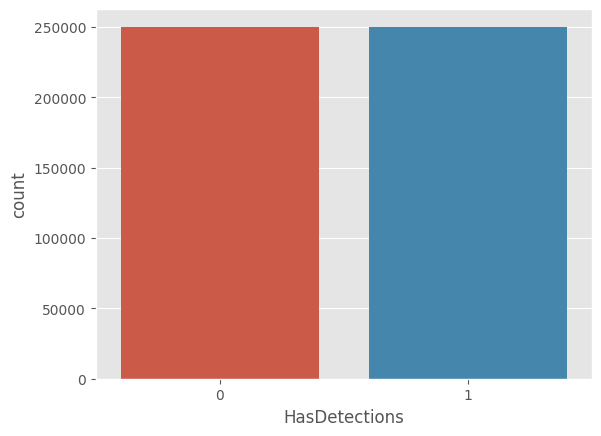

In [63]:
sns.countplot(data=df, x='HasDetections')

Vemos que el target contiene 2 valores en formato numérico:
- HasDetections = 1
- HasDetections = 0

In [64]:
df['HasDetections'].mean()

0.499906

#### 7. Distribución de variables y correlación con el target

In [71]:
pd.set_option('display.max_columns', 85)

In [72]:
df.head()

,Unnamed: 0,MachineIdentifier,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,DefaultBrowsersIdentifier,AVProductStatesIdentifier,AVProductsInstalled,AVProductsEnabled,HasTpm,CountryIdentifier,CityIdentifier,OrganizationIdentifier,GeoNameIdentifier,LocaleEnglishNameIdentifier,Platform,Processor,OsVer,OsBuild,OsSuite,OsPlatformSubRelease,OsBuildLab,SkuEdition,IsProtected,AutoSampleOptIn,PuaMode,SMode,IeVerIdentifier,SmartScreen,Firewall,UacLuaenable,Census_MDC2FormFactor,Census_DeviceFamily,Census_OEMNameIdentifier,Census_OEMModelIdentifier,Census_ProcessorCoreCount,Census_ProcessorManufacturerIdentifier,Census_ProcessorModelIdentifier,Census_ProcessorClass,Census_PrimaryDiskTotalCapacity,Census_PrimaryDiskTypeName,Census_SystemVolumeTotalCapacity,Census_HasOpticalDiskDrive,Census_TotalPhysicalRAM,Census_ChassisTypeName,Census_InternalPrimaryDiagonalDisplaySizeInInches,Census_InternalPrimaryDisplayResolutionHorizontal,Census_InternalPrimaryDisplayResolutionVertical,Census_PowerPlatformRoleName,Census_InternalBatteryType,Census_InternalBatteryNumberOfCharges,Census_OSVersion,Census_OSArchitecture,Census_OSBranch,Census_OSBuildNumber,Census_OSBuildRevision,Census_OSEdition,Census_OSSkuName,Census_OSInstallTypeName,Census_OSInstallLanguageIdentifier,Census_OSUILocaleIdentifier,Census_OSWUAutoUpdateOptionsName,Census_IsPortableOperatingSystem,Census_GenuineStateName,Census_ActivationChannel,Census_IsFlightingInternal,Census_IsFlightsDisabled,Census_FlightRing,Census_ThresholdOptIn,Census_FirmwareManufacturerIdentifier,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections
0,8427007,f1cd864e97bae82bdf96523e1a539121,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1234.0,0,7.00,0,NaN,"53,447.00",1.00,1.00,1,8,"85,219.00",NaN,205.00,172,windows10,x64,10.0.0.0,17134,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,1.00,0,NaN,0.00,137.00,RequireAdmin,1.00,1.00,Desktop,Windows.Desktop,"1,443.00","275,891.00",4.00,5.00,"2,273.00",NaN,"953,869.00",HDD,"952,838.00",0,"8,192.00",AllinOne,23.00,"1,920.00","1,080.00",Desktop,NaN,"4,294,967,295.00",10.0.17134.165,amd64,rs4_release,17134,165,Professional,PROFESSIONAL,UUPUpgrade,27.00,120,FullAuto,0,IS_GENUINE,OEM:DM,NaN,0.00,Retail,NaN,355.00,"19,951.00",0,NaN,0.00,0,0,0.00,0.00,11.00,1
1,8829090,fd5ba6f5b75325ec0423a6c67cc75942,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1282.0,0,7.00,0,NaN,"53,447.00",1.00,1.00,1,129,"54,198.00",NaN,126.00,124,windows10,x64,10.0.0.0,17134,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,1.00,0,NaN,0.00,137.00,RequireAdmin,1.00,1.00,Notebook,Windows.Desktop,"2,102.00","248,850.00",4.00,5.00,"2,660.00",NaN,"476,940.00",HDD,"457,600.00",0,"8,192.00",Notebook,13.20,"1,280.00",720.00,Mobile,lion,0.00,10.0.17134.165,amd64,rs4_release,17134,165,Professional,PROFESSIONAL,UUPUpgrade,18.00,72,FullAuto,0,IS_GENUINE,OEM:DM,NaN,0.00,Retail,0.00,486.00,"48,753.00",0,0.00,0.00,0,0,0.00,1.00,3.00,0
2,2731904,4e628391e7cc7c482fb3286f486dbd25,win8defender,1.1.15100.1,4.9.10586.1106,1.273.781.0,0,7.00,0,NaN,"46,781.00",2.00,1.00,1,149,"122,689.00",27.00,181.00,56,windows10,x64,10.0.0.0,10586,768,th2,10586.1176.amd64fre.th2_release_sec.170913-1848,Home,1.00,0,NaN,0.00,74.00,RequireAdmin,1.00,1.00,Convertible,Windows.Desktop,"2,206.00","238,234.00",4.00,5.00,"2,998.00",NaN,"244,198.00",SSD,"221,251.00",0,"8,192.00",Notebook,15.50,"1,920.00","1,080.00",Mobile,lion,0.00,10.0.10586.1176,amd64,th2_release_sec,10586,1176,Core,CORE,Update,24.00,109,Notify,0,IS_GENUINE,Retail,NaN,0.00,Retail,0.00,554.00,"33,111.00",1,0.00,0.00,1,1,0.00,0.00,15.00,0
3,1359513,270a2e9d028144a4df12a9e3da79fba5,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1639.0,0,7.00,0,NaN,"53,447.00",1.00,1.00,1,164,"114,587.00",27.00,205.00,172,windows10,x64,10.0.0.0,17134,768,rs4,17134.1

In [68]:
# Tipos de gráficos que son interesantes de hacer:

# 1 Histogramas 
# df['VariableX'].plot(kind='hist', bins = 100)

    # 1.1 Comparativa de histogramas: 
    # df[df.HasDetections == 0]['VariableX'].plot(kind='hist', alpha=.5)
    # df[df.HasDetections == 1]['VariableX'].plot(kind='hist', alpha=.5)

# 2. box plots 
# sns.boxplot(data=df, y='VariableX')
    
    # 2.1 Comparativa variable frente a target
    # sns.boxplot(data=df, x='HasDetections', y='VariableX')

# 3. Violin plots
# sns.violinplot(data=df, y='VariableX')
    
    # 3.1 Comparativa variable frente a target
    # sns.violinplot(data=df, x='HasDetections', y='VariableX')

# 4. Series temporales del target (en base a una variable)
# plt.figure(figsize=[9,3])
# df['HasDetections'].plot()

# 5. Count plots
# plt.figure(figsize=[17,3])
# plt.xticks(rotation=90)
# sns.countplot(data=df, x='VariableX', hue='HasDetections')

# 6. Métricas agragadas
# df.pivot_table(index='VariableX', values='HasDetections', aggfunc=[len, sum, np.mean]).sort_values(by=[('mean','HasDetections')], ascending = False)

# 7. Crosstab (para conteos rápidos)
# pd.crosstab(df['VariableX'], df['HasDetections'])

## MARTA: HE HECHO HASTA AQUI

## MLC3: Data Preparation

### MLC3.1: Limpieza de atributos

#### Transformación de variables

##### Númericas a categóricas

La variable OP_CARRIER_AIRLINE_ID tiene un formato numérico. Sin embargo, la variable no tiene ningún sentido ordinal, sinó que se refiere a un ID identificador de cada aerolinea. Por lo tanto, convertimos esta variable en una columna categórica.

In [105]:
df['AEROLINEA'] = df['OP_CARRIER_AIRLINE_ID'].astype(object)

In [106]:
df.select_dtypes(include=['object']).describe().T

,count,unique,top,freq
TAIL_NUM,235143,2645,N110AN,761
ORIGIN,250152,72,LAX,25345
ORIGIN_CITY_NAME,250152,70,"Los Angeles, CA",25345
ORIGIN_STATE_NM,250152,32,California,51137
DEST,250152,1,JFK,250152
DEST_CITY_NAME,250152,1,"New York, NY",250152
DEST_STATE_NM,250152,1,New York,250152
AEROLINEA,"237,644.00",11.00,"20,409.00","78,587.00"


La variable Aerolinea nos aparece ahora con 11 registros únicos (11 aerolineas distintas), siendo la aerolinea con ID 20409 la más frecuente con 78775 vuelos operados.

Como ya hemos creado una variable categórica para la Aerolinea, podemos eliminar la variable origen con formato numérico

In [107]:
df.drop('OP_CARRIER_AIRLINE_ID', axis=1, inplace=True)

#### Imputación de nulos

##### Categóricas

El primer paso a realizar en cuanto a preparación de atributos es la Limpieza de nulos. Para ello, vamos a observar la cantidad de nulos que tenemos en variables numéricas y categóricas.

In [108]:
df.select_dtypes(include=['object']).isnull().sum()

,0
TAIL_NUM,15009
ORIGIN,0
ORIGIN_CITY_NAME,0
ORIGIN_STATE_NM,0
DEST,0
DEST_CITY_NAME,0
DEST_STATE_NM,0
AEROLINEA,12508


-> **Tail number**

Podéis ver que la variable Tail_NUM tiene 15009 nulos. Podemos ver la distribución de esta variable mediante value_counts.

Esta variable contiene mucha información interesante. Por ejemplo:
* mediante fuentes de datos externas, podemos encontrar la fecha del primer vuelo del avión.
* las dos últimas letras refieren a la aerolinea que está utilizando el avión
* la letra inicial se refiere al país en el que el avión está registrado. En este dataset son todos N (USA).

In [109]:
df['TAIL_NUM'].value_counts(dropna=False)

,count
TAIL_NUM,
NaN,15009
N110AN,761
N113AN,751
N111ZM,748
N115NN,740
...,...
N197UW,1
N986AN,1
N315RJ,1


In [110]:
pd.DataFrame.fillna?

El método **fillna()** de pandas (para Series o DataFrames) permite llenar los nulos con valores específicos.\
Es importante, cuando utilicemos este método, recordar el parámetro inplace.

En este caso, podríamos rellenarlo con el valor más común, o el valor más probable por Aerolinea. Sin embargo, la presencia de nulls puede contener información relevante para el modelo. Por tanto, es conveniente rellenar los nulos con un valor diferente al resto.

In [111]:
df['TAIL_NUM'].fillna(value='ZZZ', inplace=True)

<ipython-input-111-93ddce1ea743>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TAIL_NUM'].fillna(value='ZZZ', inplace=True)


In [112]:
df.select_dtypes(include=['object']).isnull().sum()

,0
TAIL_NUM,0
ORIGIN,0
ORIGIN_CITY_NAME,0
ORIGIN_STATE_NM,0
DEST,0
DEST_CITY_NAME,0
DEST_STATE_NM,0
AEROLINEA,12508


Al rellenar nulos de una variable categórica, hay que tener en cuenta que las variables categóricas se convierten en One Hot Encodings normalmente. Si creemos que los nulos pueden contener información relevante, rellenamos los nulos con un valor único. Si no queremos mantener esta información, no es necesario realizar ningún tratamiento de nulos, ya que al hacer el OHE simplemente no se creará una columna específica para ellos.

-> **Aerolinea**

In [113]:
df['AEROLINEA'].fillna(value='ZZZ', inplace=True)

<ipython-input-113-4a314e1a1178>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AEROLINEA'].fillna(value='ZZZ', inplace=True)


##### Numéricas

In [114]:
df.select_dtypes(include=['number']).isnull().sum()

,0
CRS_DEP_TIME,0
TAXI_OUT,17511
CRS_ARR_TIME,0
ARR_DEL15,0
CRS_ELAPSED_TIME,0
DISTANCE,0
temperature_2m,0
precipitation,0
rain,0
cloudcover,0


En las variables numéricas, podemos decidir rellenar los valores nulos con cualquier valor:
1. Valores concretos
2. Valores medios o medianas (fillna lo soporta)

O bien podemos eliminar los registros que los contienen. En este caso, elegiremos un valor extremo, dado que vamos a trabajar con árboles.

In [115]:
df.fillna(value=-99999, inplace=True)

Y podemos visualizar el DataFrame resultante.

In [116]:
df.head().T

,0,1,2,3,4
FL_DATE,2018-02-01 00:00:00,2018-02-01 00:00:00,2018-02-01 00:00:00,2018-02-01 00:00:00,2018-02-01 00:00:00
TAIL_NUM,N299PQ,N920XJ,N605LR,N800AY,N600LR
ORIGIN,BNA,RDU,BUF,ORF,BOS
ORIGIN_CITY_NAME,"Nashville, TN","Raleigh/Durham, NC","Buffalo, NY","Norfolk, VA","Boston, MA"
ORIGIN_STATE_NM,Tennessee,North Carolina,New York,Virginia,Massachusetts
DEST,JFK,JFK,JFK,JFK,JFK
DEST_CITY_NAME,"New York, NY","New York, NY","New York, NY","New York, NY","New York, NY"
DEST_STATE_NM,New York,New York,New York,New York,New York
CRS_DEP_TIME,1359,1354,1529,1704,1325
TAXI_OUT,27.00,37.00,21.00,36.00,20.00


#### Eliminación de atributos de baja varianza

En este dataset, encontramos tres variables sin varianza: DEST, DEST_CITY_NAME y DEST_STATE_NM, ya que todos los resgistros de vuelo tienen como destino el aeropuerto JFK de Nueva York. Las variables sin ninguna varianza no aportan información al modelo y por lo tanto se pueden eliminar.

In [117]:
non_variance_features = ['DEST','DEST_CITY_NAME','DEST_STATE_NM']

In [118]:
df.drop(non_variance_features, axis=1, inplace=True)

#### Variables de fecha

Vamos a convertir la variable Date en una fecha y obtener algunos nuevos atributos más fáciles de tratar en el modelo, como el número de mes o de año.

In [119]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

In [120]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['Season'] = df['FL_DATE'].dt.quarter
df['Year'] = df['FL_DATE'].dt.year
df['Month'] = df['FL_DATE'].dt.month
##df['Week'] = df['FL_DATE'].dt.week
df['Weekday'] = df['FL_DATE'].dt.weekday

Es importante revisar el orden con el que genera el día de la semana ya que por convención la semana puede empezar en lunes o en domingo.

In [121]:
df.head(1)

,FL_DATE,TAIL_NUM,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,CRS_DEP_TIME,TAXI_OUT,CRS_ARR_TIME,ARR_DEL15,CRS_ELAPSED_TIME,...,cloudcover_low,cloudcover_mid,cloudcover_high,windspeed_10m,winddirection_10m,AEROLINEA,Season,Year,Month,Weekday
0,2018-02-01,N299PQ,BNA,"Nashville, TN",Tennessee,1359,27.00,1719,0.00,140.00,...,0.12,68.21,94.88,10.54,200.67,"20,363.00",1,2018,2,3


Hacemos un head del primer registro del dataset para checkear la fecha. El 1 de Diciembre de 2018 era Sábado que equivale al weeekday igual a 5. La semana empieza con 0 por lo tanto los valores 5 y 6 se corresponden al fin de semana.

In [122]:
df['Weekday'].value_counts(dropna=False)

,count
Weekday,
0,37183
4,36848
3,36679
6,36288
1,35945
2,35443
5,31766


A partir del weekday podemos generar una nueva varibale de fin de semana. Mostramso al modelo de forma explícita que día son fin de semana. Estas tranformacionesson útiles si detectamos que, por ejemplo, se concentran más retrasos en fin de semana. Sin embargo, en este caso, al modelo le es indiferente trabajar con la variable Weekend igual a 1 o weekday mayor o igual que 5 (necesita un corte en ambos casos). Esta transformación puede ser útil si por ejemplo el domingo estan codificado como 0 y el sábado como un 6. En este caso, el árbol necesitaría dos cortes para discriminar los fines de semana.

In [123]:
df['Weekend'] = (df['Weekday'] >= 5).astype(int)

In [124]:
df.drop('FL_DATE', inplace=True, axis=1)

In [125]:
df['Season'].head()

,Season
0,1
1,1
2,1
3,1
4,1


In [126]:
df['Year'].head()

,Year
0,2018
1,2018
2,2018
3,2018
4,2018


In [127]:
df['Month'].head()

,Month
0,2
1,2
2,2
3,2
4,2


#### Tratamiento de variables categóricas

En cuanto a las variables categóricas, sobre aquellas variables con pocos registros distintos, podemos realizar un One Hot Encoding. Sin embargo, por problemas de memoria en el ordenador, debemos realizar algún tipo de tratamiento sobre el resto de variables con mayor número de registros distintos.

In [128]:
df.select_dtypes(include=['object']).describe().T

,count,unique,top,freq
TAIL_NUM,250152,2646,ZZZ,15009
ORIGIN,250152,72,LAX,25345
ORIGIN_CITY_NAME,250152,70,"Los Angeles, CA",25345
ORIGIN_STATE_NM,250152,32,California,51137
AEROLINEA,"250,152.00",12.00,"20,409.00","78,587.00"


Las variables Aerolinea, origen, ciudad de origen y estado de origen son candidatas a realizar un One hot encoding. En total nos generarán hasta 184 variables, ningú problema para el árbol de decisión y en principio manejable para todos los equipos. La variable Tail number tiene 2647 registros distintos que generarían 2647 columnas nuevas. Para valorar cómo tratar esta variable, es necesario hacer un análisis más exhaustivo.

**Análisis de tail number**

In [129]:
df.pivot_table(index='TAIL_NUM', values='ARR_DEL15', aggfunc=[len, sum, np.mean]).sort_values(by=[('mean','ARR_DEL15')], ascending = False)

<ipython-input-129-5b6ad566be88>:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df.pivot_table(index='TAIL_NUM', values='ARR_DEL15', aggfunc=[len, sum, np.mean]).sort_values(by=[('mean','ARR_DEL15')], ascending = False)
<ipython-input-129-5b6ad566be88>:1: FutureWarning: The provided callable <function mean at 0x78184cb015a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.pivot_table(index='TAIL_NUM', values='ARR_DEL15', aggfunc=[len, sum, np.mean]).sort_values(by=[('mean','ARR_DEL15')], ascending = False)


,len,sum,mean
,ARR_DEL15,ARR_DEL15,ARR_DEL15
TAIL_NUM,,,
N773XF,1,1.00,1.00
N144AN,2,2.00,1.00
N812NW,1,1.00,1.00
N806SK,1,1.00,1.00
N806AW,1,1.00,1.00
...,...,...,...
N711UW,1,0.00,0.00
N523VA,1,0.00,0.00


Si ordenamos el dataset según la proporción de retrasos que tiene cada matrícula de avión, observamos que tienen una mayor proporción aviones con pocos registros de vuelos. No es una estrategia efectiva para decidir cómo tratar la variable.

En estos casos, es más efectivo ordenar los registros según el número de veces que aparecen ya que pocos registros generará una variable con poca varianza al hacer el One Hot Encoding.

In [130]:
df.pivot_table(index='TAIL_NUM', values='ARR_DEL15', aggfunc=[len, sum, np.mean]).sort_values(by=[('len','ARR_DEL15')], ascending = False)

<ipython-input-130-141ed62ee448>:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df.pivot_table(index='TAIL_NUM', values='ARR_DEL15', aggfunc=[len, sum, np.mean]).sort_values(by=[('len','ARR_DEL15')], ascending = False)
<ipython-input-130-141ed62ee448>:1: FutureWarning: The provided callable <function mean at 0x78184cb015a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.pivot_table(index='TAIL_NUM', values='ARR_DEL15', aggfunc=[len, sum, np.mean]).sort_values(by=[('len','ARR_DEL15')], ascending = False)


,len,sum,mean
,ARR_DEL15,ARR_DEL15,ARR_DEL15
TAIL_NUM,,,
ZZZ,15009,"3,109.00",0.21
N110AN,761,164.00,0.22
N113AN,751,134.00,0.18
N111ZM,748,162.00,0.22
N109NN,740,118.00,0.16
...,...,...,...
N745VJ,1,0.00,0.00
N744P,1,0.00,0.00


Observamos que el número de avión con mayor número de registros es el N110AN con 759 registros. Esto representa tan solo un 0,3% del dataset. Realizar un OHE de esta variable aportará muy poca información al modelo. Por lo tanto, decidimos realizar un frequency encoding.

#### Frequency encoding de la variable Tail Number

Vamos a hacer un conteo de el número de vuelos que realiza cada avión y sustituiremos el valor del número de vuelos por cada avión correspondiente. Con esto conseguimos sustituir la variable categórica por una de numérica. Además, mantenemos cierta información del avión, el número de vuelos puede tener relación con la antigüedad y uso del avión. En consecuencia, aviones que se utilizan más podrían ser más propensos a sufrir averias. Esto son solo hipótesis, dejaremos después que el algoritmo decida si es una buena variable.

In [131]:
df_tail_num = pd.DataFrame(df['TAIL_NUM'].value_counts(dropna = False))
df_tail_num.columns = ['TAIL_NUM_COUNT']
df_tail_num['TAIL_NUM'] = df_tail_num.index
df_tail_num.reset_index(drop=True, inplace = True)

In [132]:
#Este es el dataframe que contiene el conteo de vuelos por avión
df_tail_num.head()

,TAIL_NUM_COUNT,TAIL_NUM
0,15009,ZZZ
1,761,N110AN
2,751,N113AN
3,748,N111ZM
4,740,N115NN


Hacemos el merge con el dataframe original

In [133]:
df = df.merge(df_tail_num, on = 'TAIL_NUM')

In [134]:
#podemos eliminar la variable original ya que es categórica y ya hemos hecho el tratamiento pertinente
df.drop('TAIL_NUM', axis = 1, inplace = True)

Sobre el resto de variables categóricas, podemos realizar un OHE que nos generará un total de 186 nuevas columnas.

In [135]:
df.select_dtypes(include=['object']).describe().T

,count,unique,top,freq
ORIGIN,250152,72,LAX,25345
ORIGIN_CITY_NAME,250152,70,"Los Angeles, CA",25345
ORIGIN_STATE_NM,250152,32,California,51137
AEROLINEA,"250,152.00",12.00,"20,409.00","78,587.00"


#### One-hot-encoding for ORIGIN

In [136]:
_dummy_dataset = pd.get_dummies(df['ORIGIN'], prefix='ORIGIN')

In [137]:
df = pd.concat([df,_dummy_dataset],axis=1)

In [138]:
df.drop(['ORIGIN'],axis=1, inplace=True)

#### One-hot-encoding for CITY ORIGIN

In [139]:
_dummy_dataset = pd.get_dummies(df['ORIGIN_CITY_NAME'], prefix='ORIGIN_CITY_NAME')

In [140]:
df = pd.concat([df,_dummy_dataset],axis=1)

In [141]:
df.drop(['ORIGIN_CITY_NAME'],axis=1, inplace=True)

#### One-hot-encoding for STATE ORIGIN

In [142]:
_dummy_dataset = pd.get_dummies(df['ORIGIN_STATE_NM'], prefix='ORIGIN_STATE_NM')

In [143]:
df = pd.concat([df,_dummy_dataset],axis=1)

In [144]:
df.drop(['ORIGIN_STATE_NM'],axis=1, inplace=True)

#### One-hot-encoding for Aerolinea

In [145]:
_dummy_dataset = pd.get_dummies(df['AEROLINEA'], prefix='AEROLINEA')

In [146]:
df = pd.concat([df,_dummy_dataset],axis=1)

In [147]:
df.drop(['AEROLINEA'],axis=1, inplace=True)

#### Resultado

Finalmente, visualizaremos el DataFrame resultante.

In [148]:
df.head().T

,0,1,2,3,4
CRS_DEP_TIME,1359,1354,1529,1704,1325
TAXI_OUT,27.00,37.00,21.00,36.00,20.00
CRS_ARR_TIME,1719,1541,1709,1845,1454
ARR_DEL15,0.00,0.00,0.00,0.00,0.00
CRS_ELAPSED_TIME,140.00,107.00,100.00,101.00,89.00
DISTANCE,765.00,427.00,301.00,290.00,187.00
temperature_2m,1.12,1.12,1.12,1.12,1.12
precipitation,0.00,0.00,0.00,0.00,0.00
rain,0.00,0.00,0.00,0.00,0.00
cloudcover,69.58,69.58,69.58,69.58,69.58


In [149]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250152 entries, 0 to 250151
Columns: 207 entries, CRS_DEP_TIME to AEROLINEA_ZZZ
dtypes: bool(186), float64(13), int32(4), int64(4)
memory usage: 80.6 MB


## MLC4. Modelling

En este punto iniciamos con la fase de modelización, que ocupa los pasos de generación de la estrategia de validación, el entrenamiento del modelo y el desarrollo de predicciones y la validación de éstas.

### MLC4.1: Train / Test Split

En primer lugar, importaremos los scikits de estrategias de validación y selección de modelos **model_selection** y métricas de validación **metrics**.

In [150]:
from sklearn import model_selection # model assesment and model selection strategies
from sklearn import metrics # model evaluation metrics

Podemos analizar los métodos disponibles con "??"

In [151]:
model_selection??

Y vemos que disponemos de métodos para el random holdout (**train_test_split**) y k-fold (**KFold**), además de otras aproximaciones como el LeaveOneOut u otros.

#### Generación de la partición de validación

Como hemos comentado, este dataset está particinado temporalmente, de manera que tenemos un registro por fecha, hora y avión. En este tipo de casos, es adecuado guardar las particiones más recientes para hacer la validación del modelo, contrastando que nuestro modelo tiene capacidad de generalización hacia delante; aunque es de esperar que el patrón de comportamiento de los retrasos no tenga grandes variaciones en medida "año", es una buena práctica que se recomienda mantener y que será muy relevante en casos en los que el comportamiento a predecir evolucione en períodos breves de tiempo.

Para ello, vamos a ver cuántos registros tenemos de cada año, y con esto estableceremos qué particiones queremos utilizar para validación.

In [152]:
df['Year'].value_counts()

,count
Year,
2018,125483
2019,124669


De manera complementaria, podemos analizar la tasa en cada partición año-mes

In [153]:
df.pivot_table(index=['Year','Month'], values='ARR_DEL15', aggfunc=[len, sum, np.mean])

<ipython-input-153-6436b5a7e358>:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df.pivot_table(index=['Year','Month'], values='ARR_DEL15', aggfunc=[len, sum, np.mean])
<ipython-input-153-6436b5a7e358>:1: FutureWarning: The provided callable <function mean at 0x78184cb015a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.pivot_table(index=['Year','Month'], values='ARR_DEL15', aggfunc=[len, sum, np.mean])


len       sum      mean
           ARR_DEL15 ARR_DEL15 ARR_DEL15
Year Month                              
2018 1          9244  1,968.00      0.21
     2          9115  1,418.00      0.16
     3          9927  1,825.00      0.18
     4         10393  2,184.00      0.21
     5         10915  2,478.00      0.23
     6         11052  2,504.00      0.23
     7         11201  3,463.00      0.31
     8         11202  3,345.00      0.30
     9         10591  2,304.00      0.22
     10        10952  1,628.00      0.15
     11        10194  2,138.00      0.21
     12        10697  2,199.00      0.21
2019 1         10245  2,154.00      0.21
     2          9381  1,817.00      0.19
     3         11084  1,812.00      0.16
     4         10308  2,236.00      0.22
     5         10797  2,122.00      0.20
     6         10543  2,743.00      0.26
     7         10661  2,735.00      0.26
     8         10782  2,912.00      0.27
     9         10120  1,544.00      0.15
     10        10426  1,418.00      0.14
     11         9937  1,205.00      0.12
     12        10385  2,480.00      0.24

Para este caso, podemos por ejemplo validar con los últimos 6 meses de 2019 y utilizar 2018 y los 6 primeros de 2019 para realizar el entrenamiento del modelo (train y test). Para seleccionarlo, utilizaremos de nuevo el boolean indexing.

In [154]:
dev_df = df[(df['Year'] == 2018) | (df['Month'] < 7) ] # development = train + test
val_df = df[(df['Year'] == 2019) & (df['Month'] >= 7)] # validation

In [155]:
dev_df.shape

(187841, 207)

In [156]:
val_df.shape

(62311, 207)

Una vez realizada la selección de particiones, vamos a asignar los atributos y el target a las variables X e y, respectivamente.\
Para seleccionar, utilizaremos el método Drop sin el atributo inplace y haciendo asignación y la indexación directa (ojo con el doble claudator, usaremos un DataFrame... si usasemos el claudator simple sacaríamos una Serie).

In [157]:
dev_df_X = dev_df.drop('ARR_DEL15', axis=1)
dev_df_y = dev_df[['ARR_DEL15']]

In [158]:
val_df_X = val_df.drop('ARR_DEL15', axis=1)
val_df_y = val_df[['ARR_DEL15']]

In [159]:
dev_df_X.head().T

,0,1,2,3,4
CRS_DEP_TIME,1359,1354,1529,1704,1325
TAXI_OUT,27.00,37.00,21.00,36.00,20.00
CRS_ARR_TIME,1719,1541,1709,1845,1454
CRS_ELAPSED_TIME,140.00,107.00,100.00,101.00,89.00
DISTANCE,765.00,427.00,301.00,290.00,187.00
temperature_2m,1.12,1.12,1.12,1.12,1.12
precipitation,0.00,0.00,0.00,0.00,0.00
rain,0.00,0.00,0.00,0.00,0.00
cloudcover,69.58,69.58,69.58,69.58,69.58
cloudcover_low,0.12,0.12,0.12,0.12,0.12


In [160]:
dev_df_y.head().T

,0,1,2,3,4
ARR_DEL15,0.00,0.00,0.00,0.00,0.00


#### Random Holdout

In [161]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
                                        dev_df_X, # X
                                        dev_df_y, # y
                                        test_size = 0.30, # tamaño del split aleatorio
                                        random_state = 42
                                     )

In [162]:
X_train.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
Index: 131488 entries, 223238 to 184269
Columns: 206 entries, CRS_DEP_TIME to AEROLINEA_ZZZ
dtypes: bool(186), float64(12), int32(4), int64(4)
memory usage: 42.4 MB


In [163]:
X_test.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
Index: 56353 entries, 71883 to 82590
Columns: 206 entries, CRS_DEP_TIME to AEROLINEA_ZZZ
dtypes: bool(186), float64(12), int32(4), int64(4)
memory usage: 18.2 MB


In [164]:
X_train.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
CRS_DEP_TIME,"131,488.00","1,336.68",526.53,3.00,915.00,"1,300.00","1,744.00","2,359.00"
TAXI_OUT,"131,488.00","-7,005.49","25,557.46","-99,999.00",12.00,15.00,21.00,162.00
CRS_ARR_TIME,"131,488.00","1,419.95",580.16,1.00,943.00,"1,458.00","1,912.00","2,400.00"
CRS_ELAPSED_TIME,"131,488.00",195.29,97.43,47.00,108.00,167.00,306.00,595.00
DISTANCE,"131,488.00","1,255.78",898.69,94.00,427.00,"1,028.00","2,248.00","4,983.00"


In [165]:
X_test.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
CRS_DEP_TIME,"56,353.00","1,338.02",526.35,4.00,918.00,"1,300.00","1,745.00","2,359.00"
TAXI_OUT,"56,353.00","-7,107.54","25,728.47","-99,999.00",12.00,15.00,21.00,166.00
CRS_ARR_TIME,"56,353.00","1,417.34",579.85,1.00,940.00,"1,456.00","1,907.00","2,400.00"
CRS_ELAPSED_TIME,"56,353.00",195.11,97.31,47.00,108.00,167.00,306.00,595.00
DISTANCE,"56,353.00","1,254.73",898.33,94.00,427.00,"1,028.00","2,248.00","4,983.00"


In [166]:
y_train.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
ARR_DEL15,"131,488.00",0.21,0.41,0.00,0.00,0.00,0.00,1.00


In [167]:
y_test.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
ARR_DEL15,"56,353.00",0.21,0.41,0.00,0.00,0.00,0.00,1.00


### MLC4.2: Model definition

En primer lugar, será necesario importar los scikits de modelización

#### Import scikits

In [168]:
!conda install python-graphviz -y

/bin/bash: line 1: conda: command not found


Para visualizar árboles, es importante tener instalado la librería graphviz

!conda install graphviz -y

In [169]:
!conda install pydot -y

/bin/bash: line 1: conda: command not found


In [170]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
import graphviz

In [171]:
DecisionTreeClassifier?

A continuación, y para entrenar el modelo utilizaremos siempre el mismo procedimiento
- Instanciar el modelo (definir los parámetros)
- Realizar el entrenamiento (inducción de las reglas concretas a partir de los datos)
- Predecir (calcular la probabilidad de retraso sobre un dataset nuevo, test, que nos permita medir la bonanza del modelo)

In [172]:
dt = DecisionTreeClassifier(
                        # criterion='gini',
                        # splitter='best',
                        max_depth=4, # Importante, regulará el sobreajuste
                        # min_samples_split=2,
                        # min_samples_leaf=1,
                        # min_weight_fraction_leaf=0.0,
                        # max_features=None,
                        random_state=42,
                        # max_leaf_nodes=None,
                        # min_impurity_decrease=0.0,
                        # min_impurity_split=None,
                        # class_weight=None,
                        # presort=False,
                )

In [173]:
dt.fit?

In [174]:
dt.fit(
    X=X_train,
    y=y_train,
    # sample_weight=None,
    # check_input=True,
    # X_idx_sorted=None
)

DecisionTreeClassifier(max_depth=4, random_state=42)

Una vez generado el árbol, podemos pasar a visualizarlo con export_graphviz.

In [175]:
export_graphviz?

In [176]:
dot_data = export_graphviz(
                        decision_tree = dt,
                        out_file=None,
                        # max_depth=None,
                        feature_names=X_test.columns,
                        class_names=['No delay', 'Delay'],
                        # label='all',
                        filled=True,
                        # leaves_parallel=False,
                        impurity=True,
                        # node_ids=False,
                        proportion=True,
                        rotate=True,
                        rounded=True,
                        # special_characters=False,
                        precision=4,
                        )

In [177]:
import pydotplus
graph2 = pydotplus.graph_from_dot_data(dot_data)

In [178]:
graph2.write_png("tree.png")

True

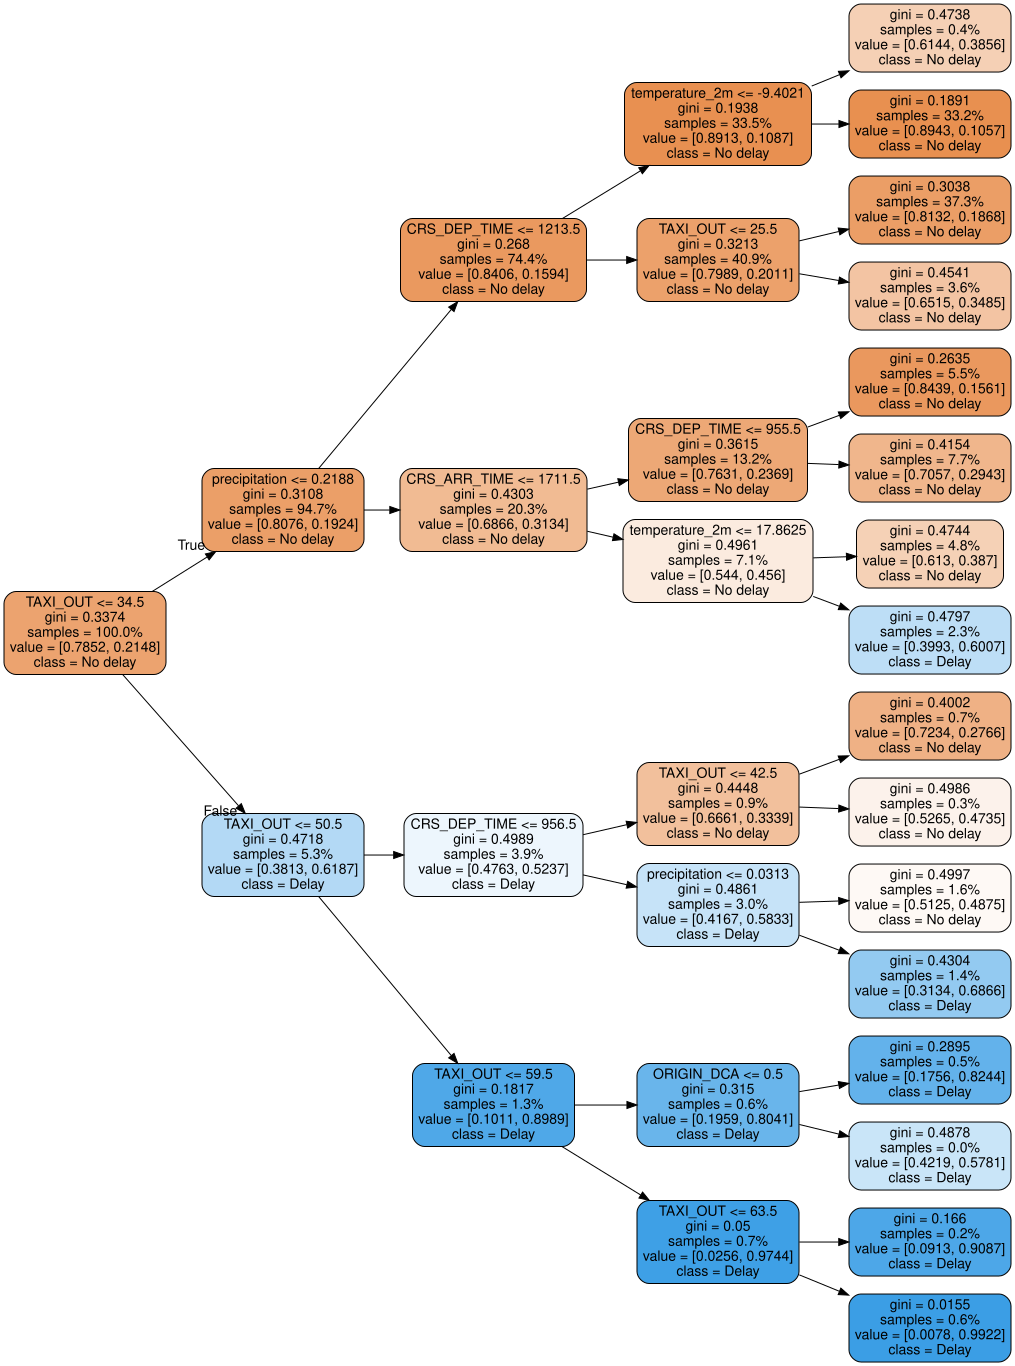

In [179]:
graphviz.Source(dot_data, format = 'png')

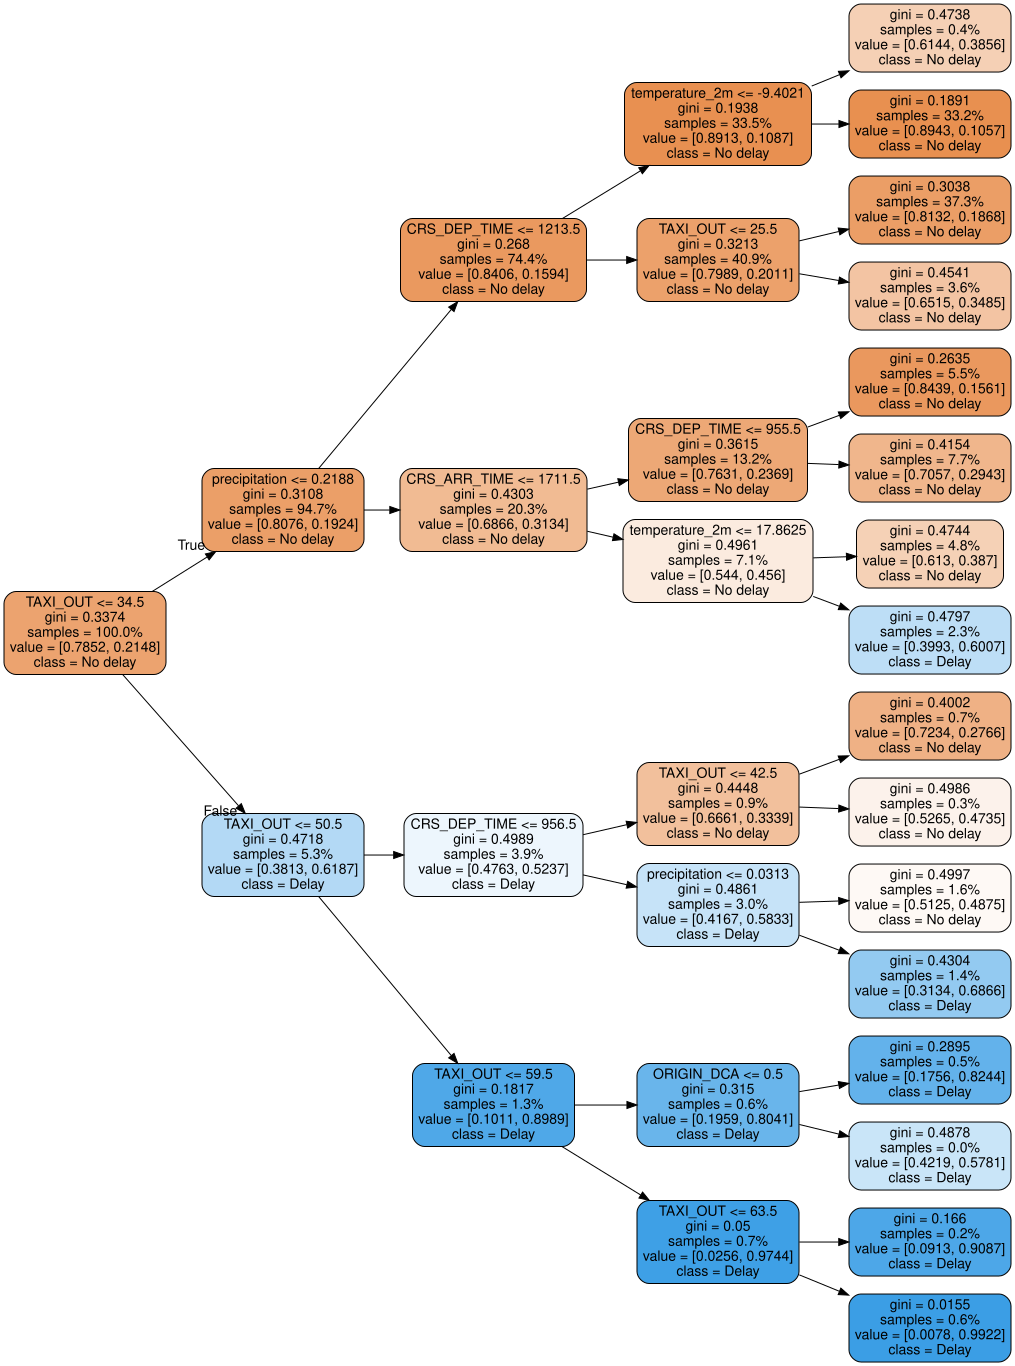

In [180]:
graph = graphviz.Source(dot_data)
graph

De la lectura del árbol se ve que la variable más relevante es TAXI_OUT . Cuando toma valores mayores a 34.5, la probabilidad de delay pasa de un 21.48% a un 61.87%, y esto aplica para el 5.3% de los ejemplos. Si es mayor a 50.5%, la probabilidad pasa al 89.89%.

Podemos hacer un análisis unidimensional de esta variable con las técnicas que hemos visto antes.

In [181]:
df_taxi_out_not_null = df[(df['TAXI_OUT'] >= 0)]

<Axes: xlabel='ARR_DEL15', ylabel='TAXI_OUT'>

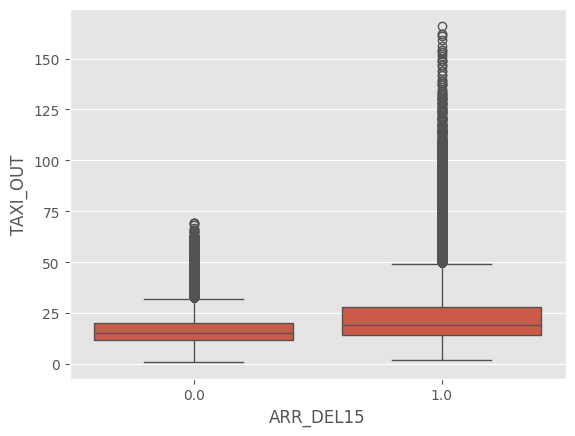

In [182]:
sns.boxplot(data=df_taxi_out_not_null, x='ARR_DEL15', y='TAXI_OUT' )

<Axes: xlabel='ARR_DEL15', ylabel='CRS_DEP_TIME'>

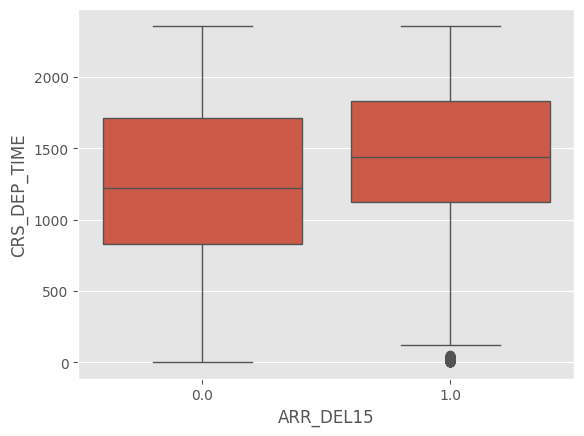

In [183]:
sns.boxplot(data=df, x='ARR_DEL15', y='CRS_DEP_TIME' )

### MLC4.3: Model evaluation

#### Opción 1: a través de los resultados

In [184]:
y_test_pred = pd.DataFrame(dt.predict(X_test), index=y_test.index, columns=['DelayPrediction'])

In [185]:
y_test_pred.head()

,DelayPrediction
71883,0.00
221437,0.00
184033,0.00
91377,0.00
25679,0.00


In [186]:
y_test.head()

,ARR_DEL15
71883,1.00
221437,1.00
184033,0.00
91377,0.00
25679,0.00


In [187]:
y_test.shape

(56353, 1)

In [188]:
y_test_pred.shape

(56353, 1)

In [189]:
results_df = y_test.join(y_test_pred, how= 'inner')

In [190]:
results_df['Success'] = (results_df['ARR_DEL15'] == results_df['DelayPrediction']).astype(int)

In [191]:
results_df.head(20)

,ARR_DEL15,DelayPrediction,Success
71883,1.00,0.00,0
221437,1.00,0.00,0
184033,0.00,0.00,1
91377,0.00,0.00,1
25679,0.00,0.00,1
64672,0.00,0.00,1
59125,1.00,0.00,0
72133,0.00,0.00,1
61555,0.00,0.00,1
203008,0.00,0.00,1


In [192]:
results_df['Success'].count()

56353

In [193]:
results_df['Success'].sum()

45388

In [194]:
results_df['Success'].mean()

0.805422958848686

In [195]:
print('Hemos acertado {} registros de un total de {}, por tanto el Accuracy es {}.'.format(results_df['Success'].sum(), results_df['Success'].count(), results_df['Success'].mean()))

Hemos acertado 45388 registros de un total de 56353, por tanto el Accuracy es 0.805422958848686.


#### Opción 2: a través de la matriz de confusión

In [196]:
confusion_matrix = pd.crosstab(results_df['ARR_DEL15'], results_df['DelayPrediction'])

In [197]:
confusion_matrix

DelayPrediction,0.00,1.00
ARR_DEL15,,
0.00,43426,838
1.00,10127,1962


In [198]:
TP = confusion_matrix.iloc[1,1]
TN = confusion_matrix.iloc[0,0]
FP = confusion_matrix.iloc[0,1]
FN = confusion_matrix.iloc[1,0]

In [199]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
accuracy

0.805422958848686

#### Opción 3: Usando el módulo metrics

In [200]:
metrics.accuracy_score(results_df['ARR_DEL15'], results_df['DelayPrediction'])

0.805422958848686

#### Opción 4: Usando el modelo

In [201]:
dt.score(X_test, y_test)

0.805422958848686

Normalmente, usaremos esta forma (el score del modelo) por comodidad, pero es bueno ser capaces de generar los distintos métodos para obtener la puntuación para ver otros casos (por ejemplo, que tal han validado las días según mes) (No somos Noob, somos Pro).

#### Validación por mes

In [202]:
results_df.head().T

,71883,221437,184033,91377,25679
ARR_DEL15,1.00,1.00,0.00,0.00,0.00
DelayPrediction,0.00,0.00,0.00,0.00,0.00
Success,0.00,0.00,1.00,1.00,1.00


In [203]:
results_df['Year'] = X_test['Year']

In [204]:
results_df['Month'] = X_test['Month']

In [205]:
results_df.head()

,ARR_DEL15,DelayPrediction,Success,Year,Month
71883,1.00,0.00,0,2019,5
221437,1.00,0.00,0,2018,8
184033,0.00,0.00,1,2018,5
91377,0.00,0.00,1,2019,6
25679,0.00,0.00,1,2018,12


In [206]:
results_df.pivot_table(index=['Year', 'Month'], values='Success', aggfunc=[len, sum, np.mean])

<ipython-input-206-4fc76699a946>:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  results_df.pivot_table(index=['Year', 'Month'], values='Success', aggfunc=[len, sum, np.mean])
<ipython-input-206-4fc76699a946>:1: FutureWarning: The provided callable <function mean at 0x78184cb015a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  results_df.pivot_table(index=['Year', 'Month'], values='Success', aggfunc=[len, sum, np.mean])


len     sum    mean
           Success Success Success
Year Month                        
2018 1        2762    2240    0.81
     2        2699    2315    0.86
     3        2952    2442    0.83
     4        3044    2468    0.81
     5        3262    2585    0.79
     6        3374    2722    0.81
     7        3405    2465    0.72
     8        3430    2573    0.75
     9        3227    2571    0.80
     10       3252    2781    0.86
     11       3033    2445    0.81
     12       3181    2545    0.80
2019 1        3118    2520    0.81
     2        2831    2352    0.83
     3        3266    2750    0.84
     4        3095    2481    0.80
     5        3302    2704    0.82
     6        3120    2429    0.78

#### Otro elemento interesante es evaluar el modelo de forma probabilista, obteniendo los scorings y no el valor de predicción

In [207]:
y_score = pd.DataFrame(dt.predict_proba(X_test)[:,1], index=y_test.index, columns=['DelayScore'])

In [208]:
results_df = results_df.join(y_score)

In [209]:
results_df.head(10)

,ARR_DEL15,DelayPrediction,Success,Year,Month,DelayScore
71883,1.00,0.00,0,2019,5,0.19
221437,1.00,0.00,0,2018,8,0.16
184033,0.00,0.00,1,2018,5,0.11
91377,0.00,0.00,1,2019,6,0.11
25679,0.00,0.00,1,2018,12,0.11
64672,0.00,0.00,1,2019,4,0.35
59125,1.00,0.00,0,2019,3,0.11
72133,0.00,0.00,1,2019,5,0.11
61555,0.00,0.00,1,2019,4,0.29
203008,0.00,0.00,1,2018,1,0.11


In [210]:
results_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56353 entries, 71883 to 82590
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ARR_DEL15        56353 non-null  float64
 1   DelayPrediction  56353 non-null  float64
 2   Success          56353 non-null  int64  
 3   Year             56353 non-null  int32  
 4   Month            56353 non-null  int32  
 5   DelayScore       56353 non-null  float64
dtypes: float64(3), int32(2), int64(1)
memory usage: 4.6 MB


#### Podemos evaluar otras opciones de métrica como el F1

In [211]:
confusion_matrix

DelayPrediction,0.00,1.00
ARR_DEL15,,
0.00,43426,838
1.00,10127,1962


In [212]:
Precision = TP / (TP + FP)
Recall = TP / (TP + FN)

In [213]:
f1_score = 2 / ( 1/Precision + 1/Recall )

In [214]:
f1_score

0.2635502720128954

In [215]:
metrics.f1_score(y_test, y_test_pred)

0.26355027201289544

#### O la curva de ROC

In [216]:
print(metrics.roc_auc_score(results_df['ARR_DEL15'], results_df['DelayScore']))

0.689773509545454


In [217]:
fpr, tpr, _ = metrics.roc_curve(results_df['ARR_DEL15'], results_df['DelayScore'])

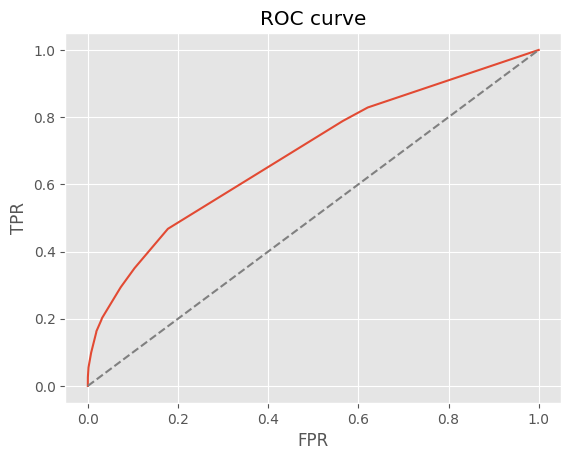

In [218]:
plt.clf()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve')
plt.show()

In [219]:
results_df.pivot_table(index='DelayScore', values='Success', aggfunc=[len, sum, np.mean])

<ipython-input-219-fc16bb087ccc>:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  results_df.pivot_table(index='DelayScore', values='Success', aggfunc=[len, sum, np.mean])
<ipython-input-219-fc16bb087ccc>:1: FutureWarning: The provided callable <function mean at 0x78184cb015a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  results_df.pivot_table(index='DelayScore', values='Success', aggfunc=[len, sum, np.mean])


,len,sum,mean
,Success,Success,Success
DelayScore,,,
0.11,18855,16784,0.89
0.16,2938,2452,0.83
0.19,21046,17167,0.82
0.28,387,270,0.70
0.29,4301,3003,0.70
0.35,2028,1347,0.66
0.39,207,130,0.63
0.39,2755,1716,0.62


In [220]:
results_by_score = results_df.pivot_table(index='DelayScore', values='Success', aggfunc=[len, sum, np.mean])

<ipython-input-220-54230ec2e9d7>:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  results_by_score = results_df.pivot_table(index='DelayScore', values='Success', aggfunc=[len, sum, np.mean])
<ipython-input-220-54230ec2e9d7>:1: FutureWarning: The provided callable <function mean at 0x78184cb015a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  results_by_score = results_df.pivot_table(index='DelayScore', values='Success', aggfunc=[len, sum, np.mean])


In [221]:
results_by_score.columns = ['Count', 'Sum', 'Mean']

<Axes: xlabel='DelayScore'>

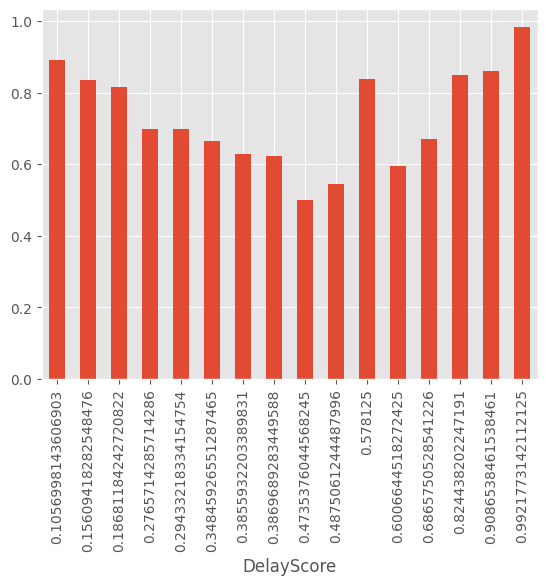

In [222]:
results_by_score['Mean'].plot(kind='bar')

#### Prueba de diversas estrategias de validación

Vamos a probar distintas estrategias de parámetros

In [223]:
for i in range(1, 20):
    dt = DecisionTreeClassifier(max_depth=i, random_state=42)
    dt.fit(X_train, y_train)
    train_accuracy = dt.score(X_train, y_train)
    test_accuracy = dt.score(X_test, y_test)
    print('Profundidad del árbol: {}. Train: {} - Test: {}'.format(i, train_accuracy, test_accuracy))

Profundidad del árbol: 1. Train: 0.797646933560477 - Test: 0.797189146984189
Profundidad del árbol: 2. Train: 0.797646933560477 - Test: 0.797189146984189
Profundidad del árbol: 3. Train: 0.8007650888293989 - Test: 0.7999041754653701
Profundidad del árbol: 4. Train: 0.8057617425164274 - Test: 0.805422958848686
Profundidad del árbol: 5. Train: 0.8104389754198101 - Test: 0.8092204496655014
Profundidad del árbol: 6. Train: 0.8139830250669262 - Test: 0.8108352705268574
Profundidad del árbol: 7. Train: 0.8182723898758822 - Test: 0.8145085443543378
Profundidad del árbol: 8. Train: 0.8225769651983451 - Test: 0.8154490444164463
Profundidad del árbol: 9. Train: 0.8284178023850085 - Test: 0.8181640728976275
Profundidad del árbol: 10. Train: 0.8363044536383548 - Test: 0.8206484126843291
Profundidad del árbol: 11. Train: 0.8436131053784376 - Test: 0.822405195819211
Profundidad del árbol: 12. Train: 0.8513248357264541 - Test: 0.8224584316717832
Profundidad del árbol: 13. Train: 0.8611508274519348 - 

En este ejemplo, podemos ver claramente como el árbol hace Overfit a medida que incrementamos la profundidad, y es por este motivo que tendremos que recurrir a mecanismos de **poda**

In [224]:
DecisionTreeClassifier??

#### Vamos a probar con algún parámetro para ver como modifican el sobreajuste.


In [225]:
for i in range(1, 20):
    dt = DecisionTreeClassifier(max_depth=i, random_state=42, min_samples_split=500)
    dt.fit(X_train, y_train)
    train_accuracy = dt.score(X_train, y_train)
    test_accuracy = dt.score(X_test, y_test)
    print('Profundidad del árbol: {}. Train: {} - Test: {}'.format(i, train_accuracy, test_accuracy))

Profundidad del árbol: 1. Train: 0.797646933560477 - Test: 0.797189146984189
Profundidad del árbol: 2. Train: 0.797646933560477 - Test: 0.797189146984189
Profundidad del árbol: 3. Train: 0.8007650888293989 - Test: 0.7999041754653701
Profundidad del árbol: 4. Train: 0.8057617425164274 - Test: 0.805422958848686
Profundidad del árbol: 5. Train: 0.8098685811633001 - Test: 0.8092204496655014
Profundidad del árbol: 6. Train: 0.8130399732294963 - Test: 0.8107997799584761
Profundidad del árbol: 7. Train: 0.8161581284984181 - Test: 0.8140116763969975
Profundidad del árbol: 8. Train: 0.8180138111462643 - Test: 0.8149166858907245
Profundidad del árbol: 9. Train: 0.8205615721586761 - Test: 0.8170993558461839
Profundidad del árbol: 10. Train: 0.8239915429544902 - Test: 0.820204780579561
Profundidad del árbol: 11. Train: 0.8245315161839863 - Test: 0.8203467428530868
Profundidad del árbol: 12. Train: 0.8246988318325627 - Test: 0.8203644881372775
Profundidad del árbol: 13. Train: 0.8254289364808955 - 

#### Podemos medir la efectividad en el conjunto de validación del mejor estimador

In [226]:
dt = DecisionTreeClassifier(max_depth=11, random_state=42, min_samples_split=500)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=11, min_samples_split=500, random_state=42)

In [227]:
dt.score(X_train, y_train)

0.8245315161839863

In [228]:
dt.score(X_test, y_test)

0.8203467428530868

In [229]:
dt.score(val_df_X, val_df_y)

0.8081398147999551

#### Podemos probar el k-fold como estrategia de validación

In [230]:
kf = model_selection.KFold(n_splits=10, random_state=42, shuffle=True)

In [231]:
scores_list = []
for train_index, test_index in kf.split(dev_df):
    #print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = dev_df_X.iloc[train_index], dev_df_X.iloc[test_index]
    y_train, y_test = dev_df_y.iloc[train_index], dev_df_y.iloc[test_index]
    dt = DecisionTreeClassifier(max_depth=8, random_state=42)
    dt.fit(X_train, y_train)
    _score = dt.score(X_test, y_test)
    scores_list.append(_score)
    #print(_scores)
scores_list

[0.8190045248868778,
 0.8122870528109029,
 0.8195804940374787,
 0.8204322827938672,
 0.815587734241908,
 0.816758943781942,
 0.8176639693356048,
 0.813458262350937,
 0.8157474446337308,
 0.8158006814310051]

In [232]:
np.mean(scores_list)

0.8166321390304254

In [233]:
np.std(scores_list)

0.0024771134906412797

In [234]:
dt = DecisionTreeClassifier(max_depth=8, random_state=42)

In [235]:
scores = model_selection.cross_val_score(dt, dev_df_X, dev_df_y, cv=kf)

In [236]:
scores

array([0.81900452, 0.81228705, 0.81958049, 0.82043228, 0.81558773,
       0.81675894, 0.81766397, 0.81345826, 0.81574744, 0.81580068])

In [237]:
print("Accuracy: %0.3f (+/- %0.3f)" % (scores.mean(), scores.std() * 2))

Accuracy: 0.817 (+/- 0.005)


### Evaluación de modelos alternativos

Una alternativa al uso de árboles de decisión que aporta mayor precisión sin perjudicar la capacidad de generalización son los modelos de Ensamble, como Random Forest o Gradient Boosting

In [238]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [239]:
RandomForestClassifier??

In [240]:
rf = RandomForestClassifier(n_estimators=3, max_depth=5, random_state=42)

In [241]:
rf.fit(
    X=X_train,
    y=np.ravel(y_train)
)

RandomForestClassifier(max_depth=5, n_estimators=3, random_state=42)

El Random Forest genera un listado de estimadores (los modelos de base) consultable, de manera que podemos trabajar con cada uno de éstos como si se tratase de un modelo independiente.

In [242]:
tree_list = rf.estimators_

In [243]:
tree_list

[DecisionTreeClassifier(max_depth=5, max_features='sqrt',
                        random_state=1608637542),
 DecisionTreeClassifier(max_depth=5, max_features='sqrt',
                        random_state=1273642419),
 DecisionTreeClassifier(max_depth=5, max_features='sqrt',
                        random_state=1935803228)]

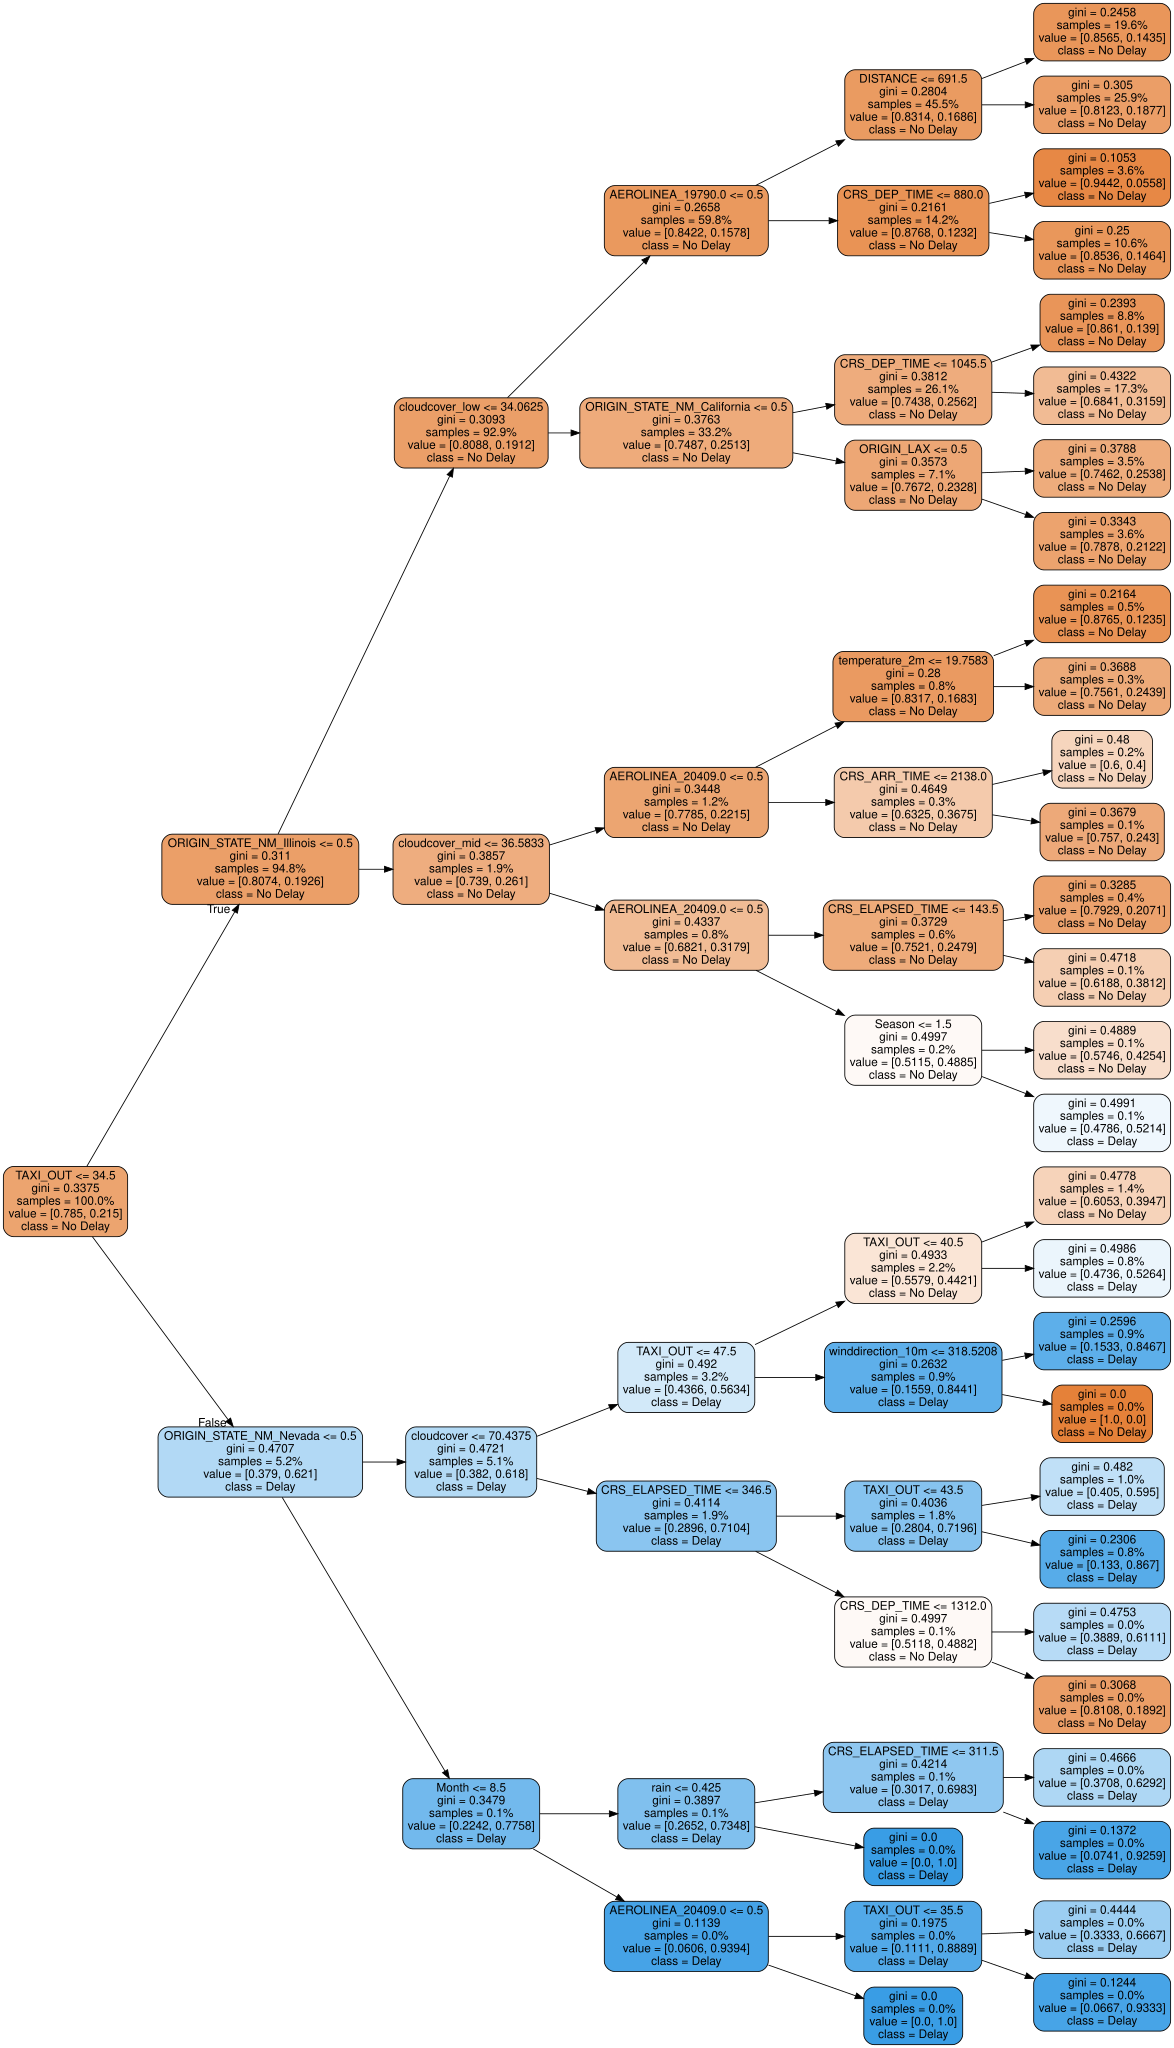

<Figure size 800x800 with 0 Axes>

In [244]:
plt.figure(figsize=(8,8))
dot_data = export_graphviz(
                        decision_tree = tree_list[0],
                        out_file=None,
                        feature_names=X_test.columns,
                        class_names=['No Delay', 'Delay'],
                        filled=True,
                        impurity=True,
                        proportion=True,
                        rotate=True,
                        rounded=True,
                        precision=4,
                        )

graph = graphviz.Source(dot_data)
graph

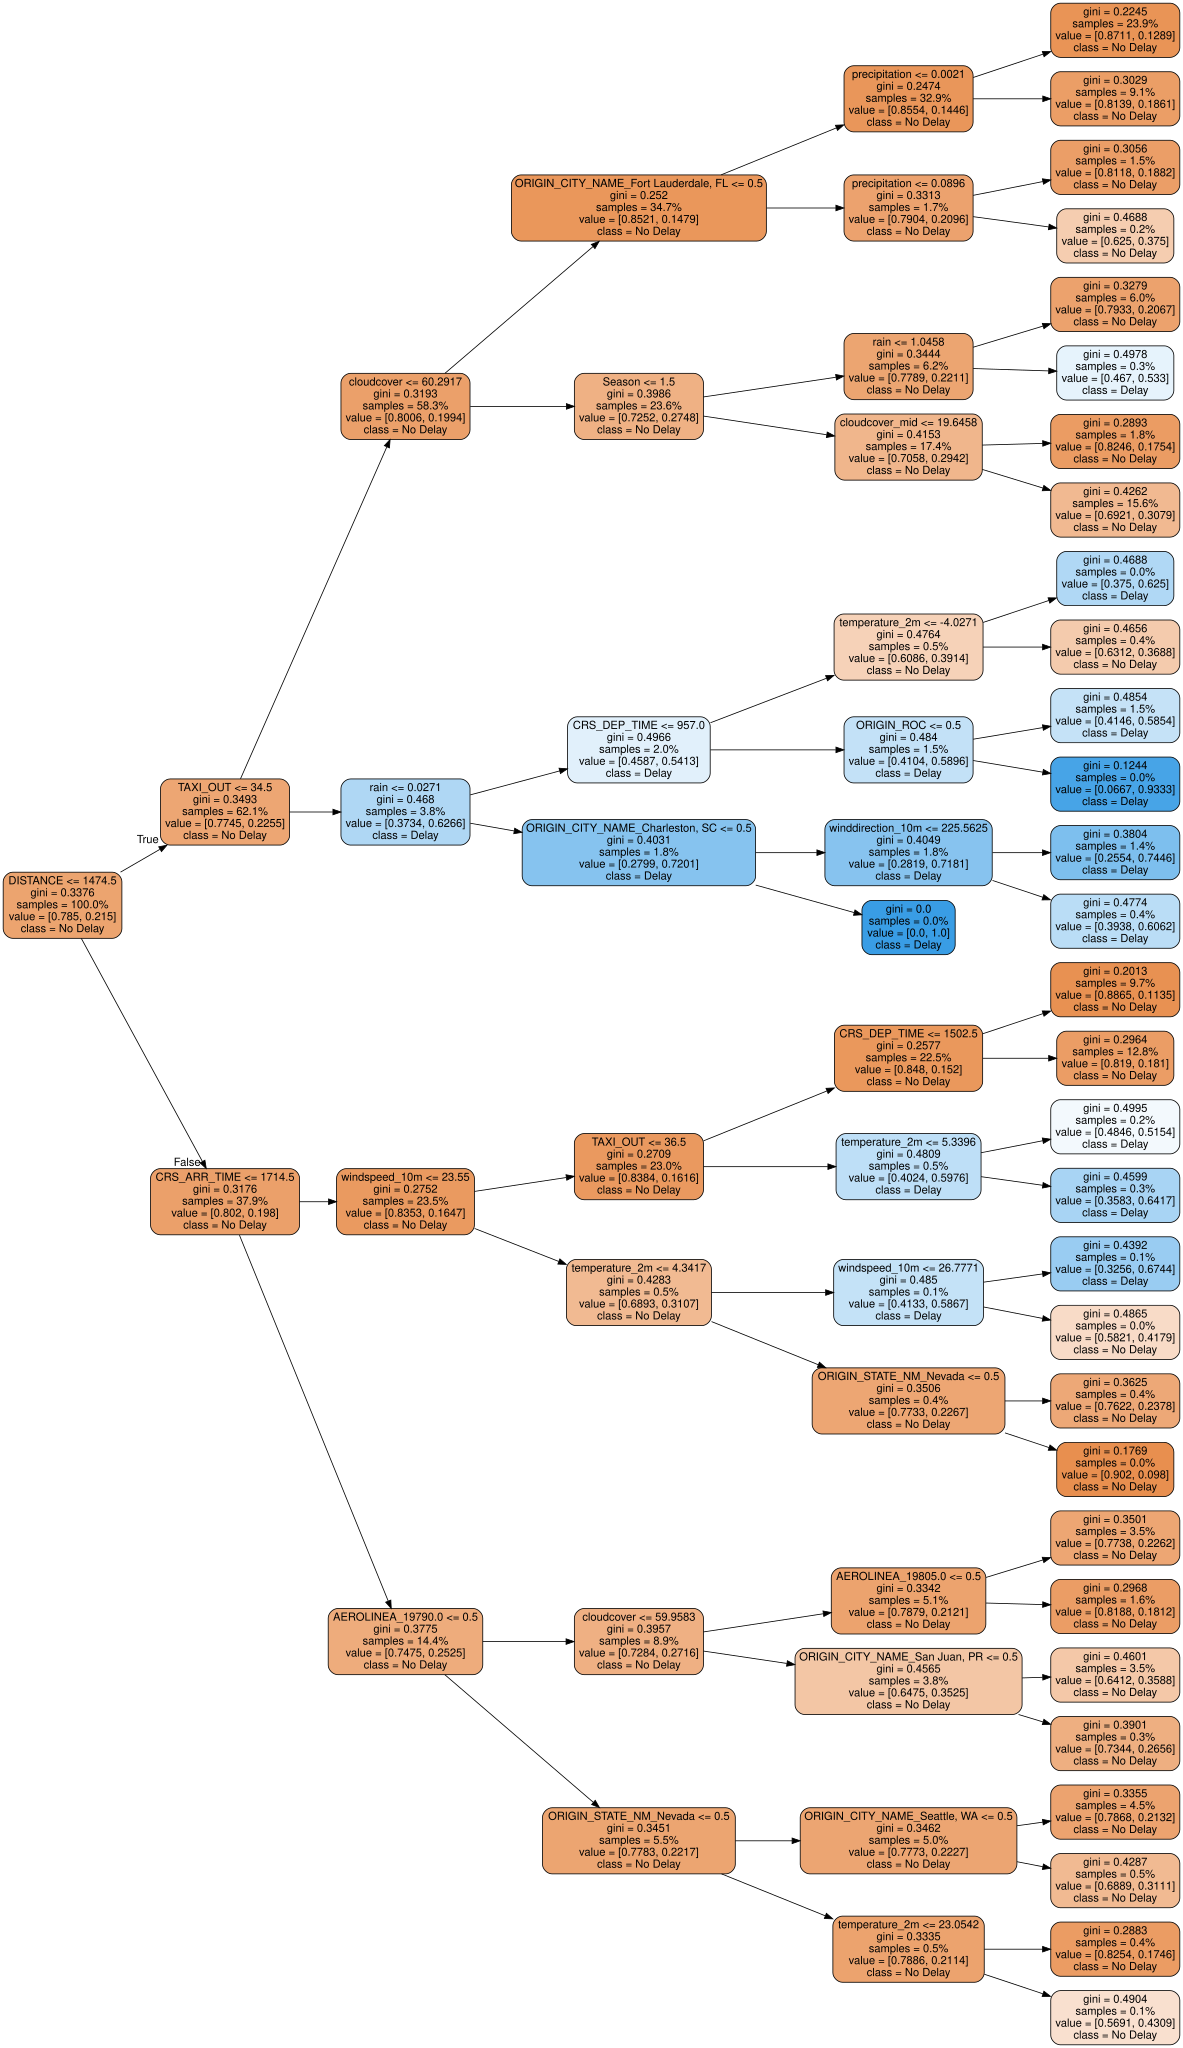

In [245]:
dot_data = export_graphviz(
                        decision_tree = tree_list[1],
                        out_file=None,
                        feature_names=X_test.columns,
                        class_names=['No Delay', 'Delay'],
                        filled=True,
                        impurity=True,
                        proportion=True,
                        rotate=True,
                        rounded=True,
                        precision=4,
                        )

graph = graphviz.Source(dot_data)
graph

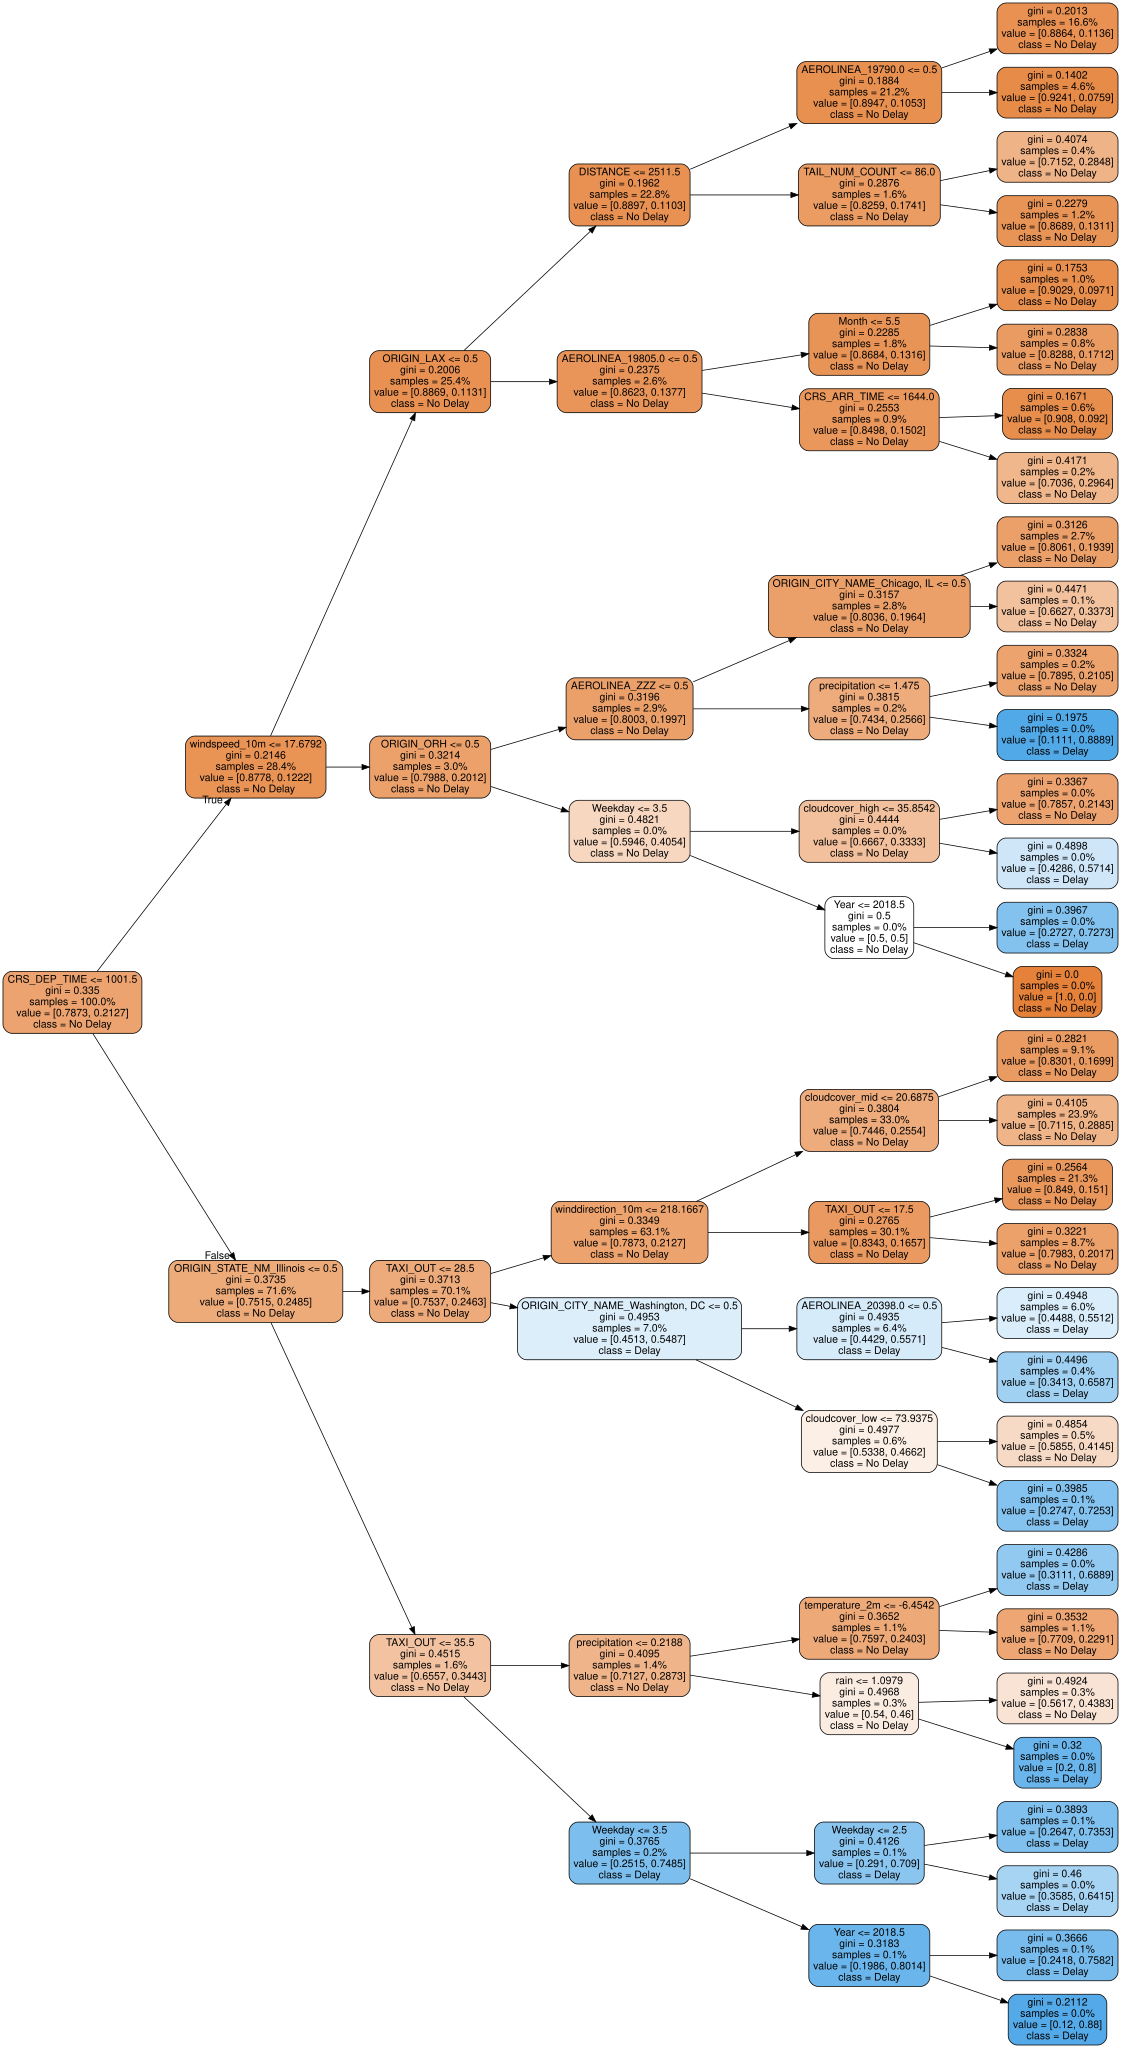

In [246]:
dot_data = export_graphviz(
                        decision_tree = tree_list[2],
                        out_file=None,
                        feature_names=X_test.columns,
                        class_names=['No Delay', 'Delay'],
                        filled=True,
                        impurity=True,
                        proportion=True,
                        rotate=True,
                        rounded=True,
                        precision=4,
                        )

graph = graphviz.Source(dot_data)
graph

Una alternativa a la visualización de importancia de atributos es el Feature Importance, que promedia el Information Gain del predictor en todo el ensamble.

In [247]:
top_features = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)

In [248]:
top_features

,0
TAXI_OUT,0.59
CRS_DEP_TIME,0.13
cloudcover,0.07
cloudcover_low,0.04
winddirection_10m,0.03
cloudcover_mid,0.03
CRS_ARR_TIME,0.02
rain,0.02
DISTANCE,0.01
precipitation,0.01


<Axes: >

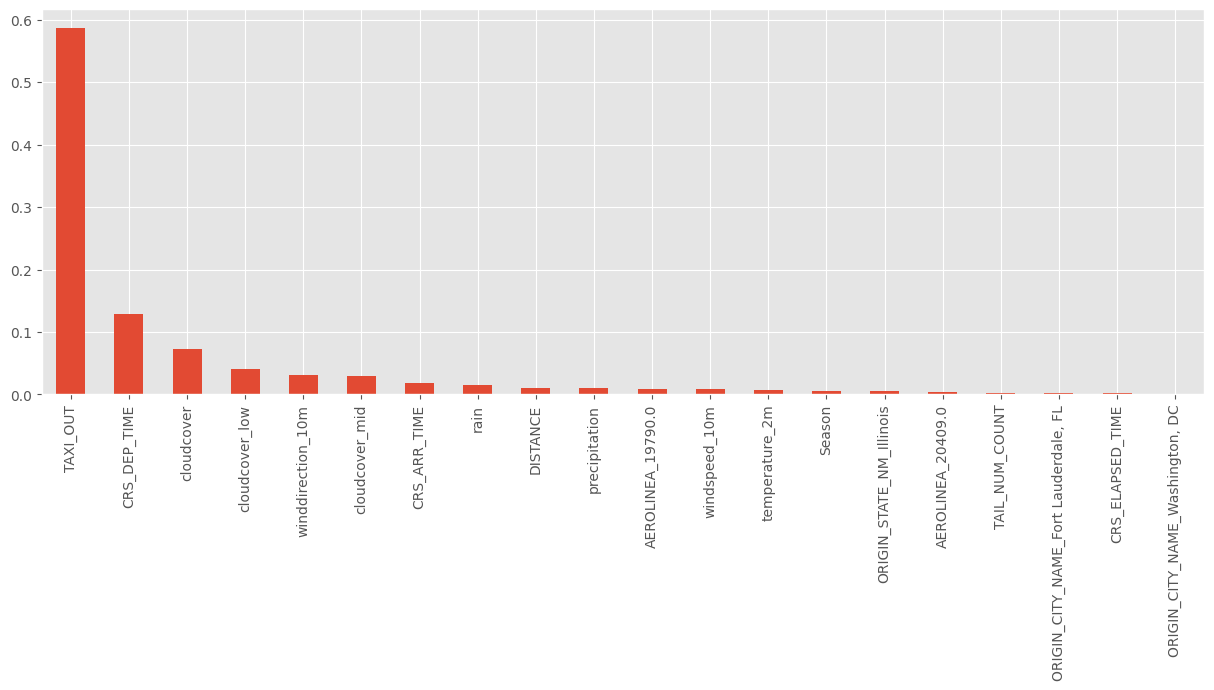

In [249]:
plt.figure(figsize=(15,5))
top_features.plot(kind='bar')

Podemos comprobar que la precisión obtenida por el RF es superior a la del árbol individual.

In [250]:
rf = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_split=500, random_state=42)
rf.fit(X_train, np.ravel(y_train))

RandomForestClassifier(max_depth=8, min_samples_split=500, random_state=42)

In [251]:
y_score = pd.DataFrame(rf.predict_proba(X_test)[:,1], index=y_test.index, columns=['DelayScore'])

In [252]:
results_df = y_test.join(y_score)

In [253]:
results_df.head(10)

,ARR_DEL15,DelayScore
5,0.00,0.18
15,0.00,0.16
26,0.00,0.19
28,1.00,0.23
36,0.00,0.25
37,0.00,0.18
45,0.00,0.18
50,0.00,0.17
55,0.00,0.19
56,0.00,0.20


In [254]:
print(metrics.roc_auc_score(results_df['ARR_DEL15'], results_df['DelayScore']))

0.7618886351099968


In [255]:
fpr, tpr, _ = metrics.roc_curve(results_df['ARR_DEL15'], results_df['DelayScore'])

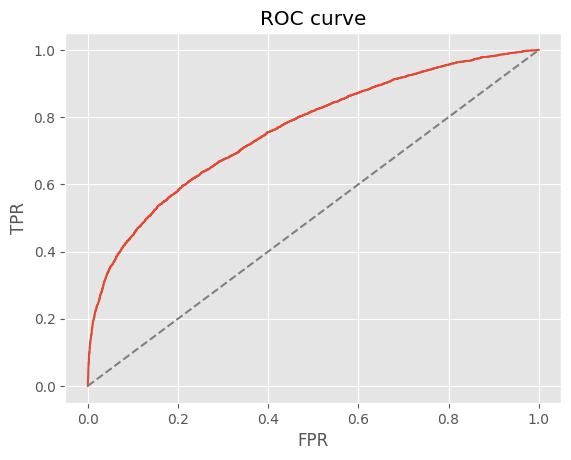

In [256]:
plt.clf()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve')
plt.show()

Un aspecto importante a tener en cuenta es que el valor de score obtenido es un valor CONTINUO, por lo que deberemos trabajar con deciles.

In [257]:
results_df['DelayScore'].nunique()

18774

In [258]:
pd.qcut?

In [259]:
results_df['Decile'] = pd.qcut(results_df['DelayScore'], q=10)

In [260]:
results_df.head(10)

,ARR_DEL15,DelayScore,Decile
5,0.00,0.18,"(0.175, 0.19]"
15,0.00,0.16,"(0.162, 0.175]"
26,0.00,0.19,"(0.19, 0.208]"
28,1.00,0.23,"(0.208, 0.234]"
36,0.00,0.25,"(0.234, 0.272]"
37,0.00,0.18,"(0.175, 0.19]"
45,0.00,0.18,"(0.175, 0.19]"
50,0.00,0.17,"(0.162, 0.175]"
55,0.00,0.19,"(0.175, 0.19]"
56,0.00,0.20,"(0.19, 0.208]"


In [261]:
results_summary_table = results_df.pivot_table(index='Decile', values='ARR_DEL15', aggfunc=[len, np.sum, np.mean]).sort_index(ascending=False)

<ipython-input-261-dff6552ad979>:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  results_summary_table = results_df.pivot_table(index='Decile', values='ARR_DEL15', aggfunc=[len, np.sum, np.mean]).sort_index(ascending=False)
<ipython-input-261-dff6552ad979>:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  results_summary_table = results_df.pivot_table(index='Decile', values='ARR_DEL15', aggfunc=[len, np.sum, np.mean]).sort_index(ascending=False)
<ipython-input-261-dff6552ad979>:1: FutureWarning: The provided callable <function sum at 0x78184cb00670> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly.

In [262]:
results_summary_table

,len,sum,mean
,ARR_DEL15,ARR_DEL15,ARR_DEL15
Decile,,,
"(0.339, 0.657]",1879,"1,299.00",0.69
"(0.272, 0.339]",1878,666.00,0.35
"(0.234, 0.272]",1878,471.00,0.25
"(0.208, 0.234]",1879,349.00,0.19
"(0.19, 0.208]",1878,341.00,0.18
"(0.175, 0.19]",1878,269.00,0.14
"(0.162, 0.175]",1879,234.00,0.12
"(0.148, 0.162]",1878,190.00,0.10


In [263]:
results_summary_table.columns = ['Cases', 'Responses', 'Accuracy']

In [264]:
results_summary_table

,Cases,Responses,Accuracy
Decile,,,
"(0.339, 0.657]",1879,"1,299.00",0.69
"(0.272, 0.339]",1878,666.00,0.35
"(0.234, 0.272]",1878,471.00,0.25
"(0.208, 0.234]",1879,349.00,0.19
"(0.19, 0.208]",1878,341.00,0.18
"(0.175, 0.19]",1878,269.00,0.14
"(0.162, 0.175]",1879,234.00,0.12
"(0.148, 0.162]",1878,190.00,0.10
"(0.132, 0.148]",1878,150.00,0.08


In [265]:
results_summary_table['Pct. Cases'] = results_summary_table['Cases'] / results_summary_table['Cases'].sum()
results_summary_table['Pct. Responses'] = results_summary_table['Responses'] / results_summary_table['Responses'].sum()

In [266]:
results_summary_table

,Cases,Responses,Accuracy,Pct. Cases,Pct. Responses
Decile,,,,,
"(0.339, 0.657]",1879,"1,299.00",0.69,0.10,0.32
"(0.272, 0.339]",1878,666.00,0.35,0.10,0.16
"(0.234, 0.272]",1878,471.00,0.25,0.10,0.12
"(0.208, 0.234]",1879,349.00,0.19,0.10,0.09
"(0.19, 0.208]",1878,341.00,0.18,0.10,0.08
"(0.175, 0.19]",1878,269.00,0.14,0.10,0.07
"(0.162, 0.175]",1879,234.00,0.12,0.10,0.06
"(0.148, 0.162]",1878,190.00,0.10,0.10,0.05
"(0.132, 0.148]",1878,150.00,0.08,0.10,0.04


In [267]:
results_summary_table['Cum. Cases'] = results_summary_table['Cases'].cumsum()
results_summary_table['Cum. Responses'] = results_summary_table['Responses'].cumsum()

In [268]:
results_summary_table

,Cases,Responses,Accuracy,Pct. Cases,Pct. Responses,Cum. Cases,Cum. Responses
Decile,,,,,,,
"(0.339, 0.657]",1879,"1,299.00",0.69,0.10,0.32,1879,"1,299.00"
"(0.272, 0.339]",1878,666.00,0.35,0.10,0.16,3757,"1,965.00"
"(0.234, 0.272]",1878,471.00,0.25,0.10,0.12,5635,"2,436.00"
"(0.208, 0.234]",1879,349.00,0.19,0.10,0.09,7514,"2,785.00"
"(0.19, 0.208]",1878,341.00,0.18,0.10,0.08,9392,"3,126.00"
"(0.175, 0.19]",1878,269.00,0.14,0.10,0.07,11270,"3,395.00"
"(0.162, 0.175]",1879,234.00,0.12,0.10,0.06,13149,"3,629.00"
"(0.148, 0.162]",1878,190.00,0.10,0.10,0.05,15027,"3,819.00"
"(0.132, 0.148]",1878,150.00,0.08,0.10,0.04,16905,"3,969.00"


In [269]:
results_summary_table['Cum. Pct. Cases'] = results_summary_table['Pct. Cases'].cumsum()
results_summary_table['Cum. Pct. Responses'] = results_summary_table['Pct. Responses'].cumsum()

In [270]:
results_summary_table

,Cases,Responses,Accuracy,Pct. Cases,Pct. Responses,Cum. Cases,Cum. Responses,Cum. Pct. Cases,Cum. Pct. Responses
Decile,,,,,,,,,
"(0.339, 0.657]",1879,"1,299.00",0.69,0.10,0.32,1879,"1,299.00",0.10,0.32
"(0.272, 0.339]",1878,666.00,0.35,0.10,0.16,3757,"1,965.00",0.20,0.48
"(0.234, 0.272]",1878,471.00,0.25,0.10,0.12,5635,"2,436.00",0.30,0.60
"(0.208, 0.234]",1879,349.00,0.19,0.10,0.09,7514,"2,785.00",0.40,0.69
"(0.19, 0.208]",1878,341.00,0.18,0.10,0.08,9392,"3,126.00",0.50,0.77
"(0.175, 0.19]",1878,269.00,0.14,0.10,0.07,11270,"3,395.00",0.60,0.84
"(0.162, 0.175]",1879,234.00,0.12,0.10,0.06,13149,"3,629.00",0.70,0.89
"(0.148, 0.162]",1878,190.00,0.10,0.10,0.05,15027,"3,819.00",0.80,0.94
"(0.132, 0.148]",1878,150.00,0.08,0.10,0.04,16905,"3,969.00",0.90,0.98


In [271]:
def get_gain_table(model, X_test, y_test):
    y_score = pd.DataFrame(model.predict_proba(X_test)[:,1], index=y_test.index, columns=['Score'])
    results_df = y_test.join(y_score)
    results_df['Decile'] = pd.qcut(results_df['Score'], q=10)
    results_summary_table = results_df.pivot_table(index='Decile', values=y_test.columns, aggfunc=[len, np.sum, np.mean]).sort_index(ascending=False)
    results_summary_table.columns = ['Cases', 'Responses', 'Accuracy']
    results_summary_table['Pct. Cases'] = results_summary_table['Cases'] / results_summary_table['Cases'].sum()
    results_summary_table['Pct. Responses'] = results_summary_table['Responses'] / results_summary_table['Responses'].sum()
    results_summary_table['Cum. Cases'] = results_summary_table['Cases'].cumsum()
    results_summary_table['Cum. Responses'] = results_summary_table['Responses'].cumsum()
    results_summary_table['Cum. Pct. Cases'] = results_summary_table['Pct. Cases'].cumsum()
    results_summary_table['Cum. Pct. Responses'] = results_summary_table['Pct. Responses'].cumsum()
    return results_summary_table

In [272]:
rf_results_summary_table = get_gain_table(rf, X_test, y_test)
rf_results_summary_table

<ipython-input-271-5923bb3090a9>:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  results_summary_table = results_df.pivot_table(index='Decile', values=y_test.columns, aggfunc=[len, np.sum, np.mean]).sort_index(ascending=False)
<ipython-input-271-5923bb3090a9>:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  results_summary_table = results_df.pivot_table(index='Decile', values=y_test.columns, aggfunc=[len, np.sum, np.mean]).sort_index(ascending=False)
<ipython-input-271-5923bb3090a9>:5: FutureWarning: The provided callable <function sum at 0x78184cb00670> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used dir

,Cases,Responses,Accuracy,Pct. Cases,Pct. Responses,Cum. Cases,Cum. Responses,Cum. Pct. Cases,Cum. Pct. Responses
Decile,,,,,,,,,
"(0.339, 0.657]",1879,"1,299.00",0.69,0.10,0.32,1879,"1,299.00",0.10,0.32
"(0.272, 0.339]",1878,666.00,0.35,0.10,0.16,3757,"1,965.00",0.20,0.48
"(0.234, 0.272]",1878,471.00,0.25,0.10,0.12,5635,"2,436.00",0.30,0.60
"(0.208, 0.234]",1879,349.00,0.19,0.10,0.09,7514,"2,785.00",0.40,0.69
"(0.19, 0.208]",1878,341.00,0.18,0.10,0.08,9392,"3,126.00",0.50,0.77
"(0.175, 0.19]",1878,269.00,0.14,0.10,0.07,11270,"3,395.00",0.60,0.84
"(0.162, 0.175]",1879,234.00,0.12,0.10,0.06,13149,"3,629.00",0.70,0.89
"(0.148, 0.162]",1878,190.00,0.10,0.10,0.05,15027,"3,819.00",0.80,0.94
"(0.132, 0.148]",1878,150.00,0.08,0.10,0.04,16905,"3,969.00",0.90,0.98


In [273]:
gb = GradientBoostingClassifier(n_estimators=50, max_depth=5, min_samples_split=500, random_state=42)
gb.fit(X_train, np.ravel(y_train))

GradientBoostingClassifier(max_depth=5, min_samples_split=500, n_estimators=50,
                           random_state=42)

In [274]:
y_score = pd.DataFrame(gb.predict_proba(X_test)[:,1], index=y_test.index, columns=['DelayScore'])

In [275]:
results_df = y_test.join(y_score)

In [276]:
print(metrics.roc_auc_score(results_df['ARR_DEL15'], results_df['DelayScore']))

0.7893101666867723


In [277]:
gb_results_summary_table = get_gain_table(gb, X_test, y_test)
gb_results_summary_table

<ipython-input-271-5923bb3090a9>:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  results_summary_table = results_df.pivot_table(index='Decile', values=y_test.columns, aggfunc=[len, np.sum, np.mean]).sort_index(ascending=False)
<ipython-input-271-5923bb3090a9>:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  results_summary_table = results_df.pivot_table(index='Decile', values=y_test.columns, aggfunc=[len, np.sum, np.mean]).sort_index(ascending=False)
<ipython-input-271-5923bb3090a9>:5: FutureWarning: The provided callable <function sum at 0x78184cb00670> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used dir

,Cases,Responses,Accuracy,Pct. Cases,Pct. Responses,Cum. Cases,Cum. Responses,Cum. Pct. Cases,Cum. Pct. Responses
Decile,,,,,,,,,
"(0.455, 0.965]",1879,"1,377.00",0.73,0.10,0.34,1879,"1,377.00",0.10,0.34
"(0.293, 0.455]",1878,719.00,0.38,0.10,0.18,3757,"2,096.00",0.20,0.52
"(0.224, 0.293]",1878,470.00,0.25,0.10,0.12,5635,"2,566.00",0.30,0.63
"(0.186, 0.224]",1879,385.00,0.20,0.10,0.09,7514,"2,951.00",0.40,0.73
"(0.157, 0.186]",1878,312.00,0.17,0.10,0.08,9392,"3,263.00",0.50,0.80
"(0.132, 0.157]",1878,232.00,0.12,0.10,0.06,11270,"3,495.00",0.60,0.86
"(0.113, 0.132]",1879,200.00,0.11,0.10,0.05,13149,"3,695.00",0.70,0.91
"(0.0966, 0.113]",1878,157.00,0.08,0.10,0.04,15027,"3,852.00",0.80,0.95
"(0.0794, 0.0966]",1878,126.00,0.07,0.10,0.03,16905,"3,978.00",0.90,0.98


### Comparación de modelos

In [278]:
RANDOM_STATE = 42
n_estimators = 50
max_depth = 5

models = [
    ('DecisionTree', DecisionTreeClassifier(max_depth=max_depth, random_state=42)),
    ('RandomForest', RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=RANDOM_STATE)),
    ('GradientBoosting', GradientBoostingClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=RANDOM_STATE))
]

ROC AUC Score for DecisionTree: 0.7097789919129989
ROC AUC Score for RandomForest: 0.7428102239063177
ROC AUC Score for GradientBoosting: 0.7890667806090453


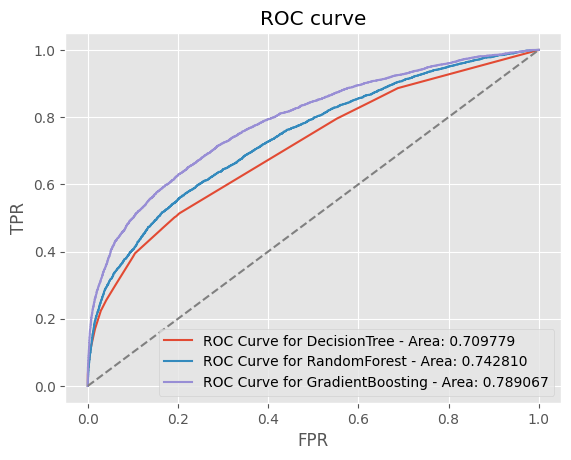

In [279]:
plt.clf()
for model in models:
    model_name = model[0]
    model_instance = model[1]
    model_instance.fit(X_train, np.ravel(y_train))
    predictions = model_instance.predict_proba(X_test)[:,1]
    auc_score = metrics.roc_auc_score(y_test, predictions)
    print('ROC AUC Score for {}: {}'.format(model_name, auc_score))
    fpr, tpr, _ = metrics.roc_curve(y_test, predictions)
    plt.plot(fpr, tpr, label='ROC Curve for {} - Area: {:2f}'.format(model_name, auc_score))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc="lower right")
plt.title('ROC curve')
plt.show()